## 1

/home/mca/Shweta/handwritten text detection/sbenv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Device : cuda
GPU    : NVIDIA RTX 5000 Ada Generation
VRAM   : 33.8 GB
Save dir : /home/mca/Shweta/handwritten text detection/saved_models/icdar_scratch
Vocab : 99 classes
Encode test : 'Hello'
Model architecture defined.

Scanning dataset...
[Dataset] Paired=3500  Total words=159804  Valid=159804  Skipped=0
Train samples : 143824
Val   samples : 15980
Train batches : 17978  |  Val batches : 1998

Model built from scratch.
Trainable parameters : 52,006,123

   ICDAR HWD 2024 — Training from Scratch


Epoch  1/30: 100%|██████████████████████████████████████████████████████████████████████████| 17978/17978 [1:10:20<00:00,  4.26it/s, cacc=100.0%, loss=0.0045, lr=1.00e-04, wacc=100.0%]



Epoch  1/30 | Train loss=0.2557  WAcc=88.52%  CAcc=92.99% | Val   loss=4.8283  WAcc=0.00%  CAcc=0.07%


Epoch  2/30: 100%|██████████████████████████████████████████████████| 17978/17978 [1:08:28<00:00,  4.38it/s, cacc=100.0%, loss=0.0258, lr=9.97e-05, wacc=100.0%]


...


Epoch  5/30 | Train loss=0.0105  WAcc=99.61%  CAcc=99.91% | Val   loss=5.0327  WAcc=0.00%  CAcc=0.14%


Epoch  6/30: 100%|██████████████████████████████████████████████████| 17978/17978 [1:04:57<00:00,  4.61it/s, cacc=100.0%, loss=0.0058, lr=9.34e-05, wacc=100.0%]



Epoch  6/30 | Train loss=0.0106  WAcc=99.60%  CAcc=99.91% | Val   loss=3.9649  WAcc=0.00%  CAcc=0.05%


Epoch  7/30: 100%|██████████████████████████████████████████████████| 17978/17978 [1:04:23<00:00,  4.65it/s, cacc=100.0%, loss=0.0075, lr=9.05e-05, wacc=100.0%]



Epoch  7/30 | Train loss=0.0104  WAcc=99.61%  CAcc=99.91% | Val   loss=4.2406  WAcc=0.00%  CAcc=0.07%

Early stopping triggered — no val WAcc improvement for 7 epochs.

Done.  Best val WAcc=0.00%  Best val loss=3.9649
Saved : /home/mca/Shweta/handwritten text detection/saved_models/icdar_scratch


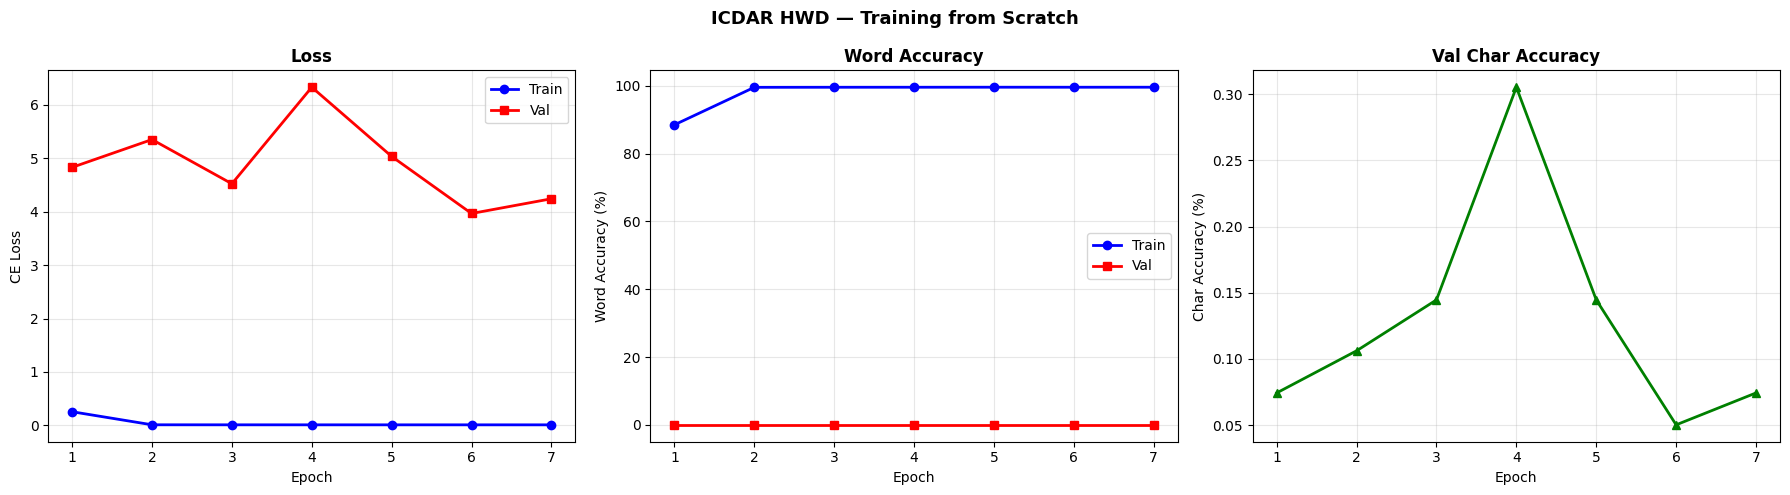

Curves saved.


FileNotFoundError: [Errno 2] No such file or directory: '/home/mca/Shweta/handwritten text detection/saved_models/icdar_scratch/best_accuracy.pth'

In [1]:
# ============================================================
#  ICDAR HWD 2024 — Train from Scratch (Single Cell)
# ============================================================

# ── 0. INSTALLS ──────────────────────────────────────────────
import subprocess
subprocess.run(['pip', 'install', 'torch', 'torchvision', 'Pillow',
                'tqdm', 'matplotlib', '--quiet'], capture_output=True)

# ── 1. IMPORTS ───────────────────────────────────────────────
import os, re, torch, torch.nn as nn, torch.optim as optim
import torch.nn.functional as F
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from tqdm import tqdm
import matplotlib.pyplot as plt

# ── 2. DEVICE ────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# ── 3. CONFIG  (EDIT PATHS HERE) ─────────────────────────────
TRAIN_DATA_DIR = '/home/mca/Shweta/handwritten text detection/dataset/Page_Level_English_Training_Set/Page_Level_Training_Set'
SAVE_DIR       = '/home/mca/Shweta/handwritten text detection/saved_models/icdar_scratch'

BATCH_SIZE       = 8
NUM_EPOCHS       = 30
LEARNING_RATE    = 1e-4
NUM_WORKERS      = 4
MAX_LABEL_LEN    = 25
IMG_H, IMG_W     = 32, 100
NUM_CLASSES      = 99
NUM_GATED_LAYERS = 6
VAL_SPLIT        = 0.1       # 10% of data held out for validation

os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save dir : {SAVE_DIR}")

# ── 4. VOCABULARY ────────────────────────────────────────────
CHARS = ' !"#$%&\'()*+,-./0123456789:;<=>?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[\\]^_`abcdefghijklmnopqrstuvwxyz{|}~'
GO_IDX, EOS_IDX, PAD_IDX, UNK_IDX = 0, 1, 2, 3
CHAR_TO_IDX = {c: i+4 for i, c in enumerate(CHARS)}
IDX_TO_CHAR = {v: k for k, v in CHAR_TO_IDX.items()}
IDX_TO_CHAR.update({0:'<GO>', 1:'<EOS>', 2:'<PAD>', 3:'<UNK>'})

def encode_label(text, max_len):
    tokens = [GO_IDX]
    for c in text[:max_len]:
        tokens.append(CHAR_TO_IDX.get(c, UNK_IDX))
    tokens.append(EOS_IDX)
    while len(tokens) < max_len + 2:
        tokens.append(PAD_IDX)
    return torch.tensor(tokens[:max_len+2], dtype=torch.long)

def decode_label(tensor):
    chars = []
    for idx in tensor.tolist():
        if idx == EOS_IDX:
            break
        if idx not in (GO_IDX, PAD_IDX, UNK_IDX):
            chars.append(IDX_TO_CHAR.get(idx, ''))
    return ''.join(chars)

print(f"Vocab : {len(CHARS)+4} classes")
print(f"Encode test : '{decode_label(encode_label('Hello', MAX_LABEL_LEN))}'")

# ── 5. DATASET ───────────────────────────────────────────────
def get_transforms(imgH, imgW, augment=False):
    ops = [transforms.Grayscale(1), transforms.Resize((imgH, imgW))]
    if augment:
        ops += [
            transforms.RandomAffine(degrees=5, translate=(0.03,0.03),
                                    scale=(0.9,1.1), shear=5),
            transforms.ColorJitter(brightness=0.4, contrast=0.4),
        ]
    ops += [transforms.ToTensor(), transforms.Normalize([0.5],[0.5])]
    return transforms.Compose(ops)


class ICDARPageDataset(Dataset):
    """
    ICDAR HWD 2024 page-level dataset.
    Each .txt has numbered sentences: '36331 Chapter One: ...'
    Splits every sentence into words — each word = one sample.
    Full page .jpg is used as the image input (resized to 32x100).
    """
    def __init__(self, data_dir, max_label_len=25,
                 imgH=32, imgW=100, augment=False, samples=None):
        self.transform     = get_transforms(imgH, imgW, augment)
        self.max_label_len = max_label_len

        # If pre-split samples list is passed in directly, use it
        if samples is not None:
            self.samples = samples
            return

        self.samples = []
        all_files = os.listdir(data_dir)
        jpg_stems = {os.path.splitext(f)[0] for f in all_files if f.lower().endswith('.jpg')}
        txt_stems = {os.path.splitext(f)[0] for f in all_files if f.lower().endswith('.txt')}
        paired    = sorted(jpg_stems & txt_stems)

        skipped = 0
        total_words = 0
        for stem in paired:
            jpg_path = os.path.join(data_dir, stem + '.jpg')
            txt_path = os.path.join(data_dir, stem + '.txt')
            try:
                raw = open(txt_path, 'r', encoding='utf-8').read()
            except Exception:
                skipped += 1
                continue

            # Parse numbered sentences: '36331 some text here...'
            parts = re.split(r'\b(\d{4,6})\s+', raw)
            i = 1
            while i < len(parts) - 1:
                sentence = parts[i+1].strip().split('\n')[0].strip()
                for word in sentence.split():
                    total_words += 1
                    if 1 <= len(word) <= max_label_len:
                        self.samples.append((jpg_path, word))
                    else:
                        skipped += 1
                i += 2

        print(f"[Dataset] Paired={len(paired)}  "
              f"Total words={total_words}  "
              f"Valid={len(self.samples)}  Skipped={skipped}")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        jpg_path, label = self.samples[idx]
        try:
            image = Image.open(jpg_path).convert('RGB')
        except Exception:
            image = Image.new('RGB', (IMG_W, IMG_H), (255, 255, 255))
        return self.transform(image), encode_label(label, self.max_label_len), label


def split_dataset(full_dataset, val_fraction, imgH, imgW):
    """Split a loaded dataset into train/val without re-scanning disk."""
    import random
    all_samples = full_dataset.samples.copy()
    random.seed(42)
    random.shuffle(all_samples)
    n_val   = max(1, int(len(all_samples) * val_fraction))
    n_train = len(all_samples) - n_val

    train_ds = ICDARPageDataset(None, MAX_LABEL_LEN, imgH, imgW,
                                augment=True,  samples=all_samples[:n_train])
    val_ds   = ICDARPageDataset(None, MAX_LABEL_LEN, imgH, imgW,
                                augment=False, samples=all_samples[n_train:])
    return train_ds, val_ds


# ── 6. MODEL ARCHITECTURE ────────────────────────────────────
class LocalizationNetwork(nn.Module):
    def __init__(self, F, I_channel_num):
        super().__init__()
        self.F = F
        self.conv = nn.Sequential(
            nn.Conv2d(I_channel_num,64,3,1,1), nn.BatchNorm2d(64),  nn.ReLU(True), nn.MaxPool2d(2,2),
            nn.Conv2d(64,128,3,1,1),           nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2,2),
            nn.Conv2d(128,256,3,1,1),          nn.BatchNorm2d(256), nn.ReLU(True), nn.MaxPool2d(2,2),
            nn.Conv2d(256,512,3,1,1),          nn.BatchNorm2d(512), nn.ReLU(True), nn.AdaptiveAvgPool2d(1),
        )
        self.fc1 = nn.Linear(512, 256)
        self.fc2 = nn.Linear(256, F*2)
        x     = np.linspace(-1.0, 1.0, int(F/2))
        y_top = np.linspace(0.0, -1.0, num=int(F/2))
        y_bot = np.linspace(1.0,  0.0, num=int(F/2))
        bias  = np.concatenate([np.stack([x,y_top],1), np.stack([x,y_bot],1)], 0)
        self.fc2.bias.data   = torch.from_numpy(bias).float().view(-1)
        self.fc2.weight.data.fill_(0)

    def forward(self, x):
        x = self.conv(x).squeeze(-1).squeeze(-1)
        return self.fc2(F.relu(self.fc1(x))).view(-1, self.F, 2)


class GridGenerator(nn.Module):
    def __init__(self, F, I_r_size):
        super().__init__()
        self.F   = F
        self.eps = 1e-6
        h, w     = I_r_size
        P        = self._build_P(w, h)
        self.register_buffer('inv_delta_C', self._build_inv_delta_C(F).float())
        self.register_buffer('P_hat',       self._build_P_hat(F, P).float())

    def _C(self):
        x = np.linspace(-1.0, 1.0, int(self.F/2))
        return np.concatenate([np.stack([x,-np.ones(int(self.F/2))],1),
                                np.stack([x, np.ones(int(self.F/2))],1)], 0)

    def _build_P(self, w, h):
        gx = (np.arange(-w,w,2)+1.0)/w
        gy = (np.arange(-h,h,2)+1.0)/h
        return np.stack(np.meshgrid(gx,gy), axis=2).reshape(-1,2)

    def _build_inv_delta_C(self, F):
        C     = self._C()
        hat_C = np.zeros((F,F))
        for i in range(F):
            for j in range(F):
                r = np.linalg.norm(C[i]-C[j])
                hat_C[i,j] = r**2 * np.log(r+self.eps)
        delta_C = np.concatenate([
            np.concatenate([np.ones((F,1)), C, hat_C],1),
            np.concatenate([np.zeros((2,3)), C.T],    1),
            np.concatenate([np.zeros((1,3)), np.ones((1,F))],1),
        ], 0)
        return torch.tensor(np.linalg.inv(delta_C))

    def _build_P_hat(self, F, P):
        C      = self._C()
        n      = P.shape[0]
        P_diff = np.tile(P[:,None,:], (1,F,1)) - C[None,:,:]
        rbf    = np.linalg.norm(P_diff, axis=2)
        rbf    = rbf**2 * np.log(rbf+self.eps)
        return torch.tensor(np.concatenate([np.ones((n,1)), P, rbf], 1))

    def build_P_prime(self, batch_C_prime):
        B = batch_C_prime.size(0)
        z = torch.cat([batch_C_prime, torch.zeros(B,3,2,device=batch_C_prime.device)], 1)
        T = torch.bmm(self.inv_delta_C.expand(B,-1,-1), z)
        return torch.bmm(self.P_hat.expand(B,-1,-1), T)


class TPSSpatialTransformerNetwork(nn.Module):
    def __init__(self, F=20, I_size=(32,100), I_r_size=(32,100), I_channel_num=1):
        super().__init__()
        self.LocalizationNetwork = LocalizationNetwork(F, I_channel_num)
        self.GridGenerator       = GridGenerator(F, I_r_size)

    def forward(self, batch_I):
        C_prime = self.LocalizationNetwork(batch_I)
        P_prime = self.GridGenerator.build_P_prime(C_prime)
        B       = P_prime.size(0)
        return F.grid_sample(batch_I, P_prime.reshape([B,32,100,2]),
                             padding_mode='border', align_corners=True)


class BasicBlock(nn.Module):
    def __init__(self, inplanes, planes, stride=1, downsample=None, dropout=0.1):
        super().__init__()
        self.conv1      = nn.Conv2d(inplanes, planes, 3, stride=stride, padding=1, bias=False)
        self.bn1        = nn.BatchNorm2d(planes)
        self.conv2      = nn.Conv2d(planes, planes, 3, padding=1, bias=False)
        self.bn2        = nn.BatchNorm2d(planes)
        self.relu       = nn.ReLU(inplace=True)
        self.dropout    = nn.Dropout2d(p=dropout)
        self.downsample = downsample

    def forward(self, x):
        res = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        if self.downsample: res = self.downsample(x)
        return self.relu(out + res)


class ResNet(nn.Module):
    def __init__(self, input_channel, output_channel, block, layers):
        super().__init__()
        ocb           = [output_channel//4, output_channel//2, output_channel, output_channel]
        self.inplanes = output_channel//8
        self.conv0_1  = nn.Conv2d(input_channel,      output_channel//16, 3,1,1, bias=False)
        self.bn0_1    = nn.BatchNorm2d(output_channel//16)
        self.conv0_2  = nn.Conv2d(output_channel//16, self.inplanes,      3,1,1, bias=False)
        self.bn0_2    = nn.BatchNorm2d(self.inplanes)
        self.relu     = nn.ReLU(inplace=True)
        self.maxpool1 = nn.MaxPool2d(2,2)
        self.layer1   = self._make_layer(block, ocb[0], layers[0])
        self.conv1    = nn.Conv2d(ocb[0], ocb[0], 3,1,1, bias=False); self.bn1 = nn.BatchNorm2d(ocb[0])
        self.maxpool2 = nn.MaxPool2d(2,2)
        self.layer2   = self._make_layer(block, ocb[1], layers[1])
        self.conv2    = nn.Conv2d(ocb[1], ocb[1], 3,1,1, bias=False); self.bn2 = nn.BatchNorm2d(ocb[1])
        self.maxpool3 = nn.MaxPool2d((2,1),(2,1))
        self.layer3   = self._make_layer(block, ocb[2], layers[2])
        self.conv3    = nn.Conv2d(ocb[2], ocb[2], 3,1,1, bias=False); self.bn3 = nn.BatchNorm2d(ocb[2])
        self.layer4   = self._make_layer(block, ocb[3], layers[3])
        self.conv4_1  = nn.Conv2d(ocb[3], ocb[3], 2,1,0,      bias=False); self.bn4_1 = nn.BatchNorm2d(ocb[3])
        self.conv4_2  = nn.Conv2d(ocb[3], ocb[3], 2,(1,1),(1,0), bias=False); self.bn4_2 = nn.BatchNorm2d(ocb[3])

    def _make_layer(self, block, planes, blocks, stride=1):
        ds = None
        if stride != 1 or self.inplanes != planes:
            ds = nn.Sequential(nn.Conv2d(self.inplanes, planes, 1, stride, bias=False),
                               nn.BatchNorm2d(planes))
        lst = [block(self.inplanes, planes, stride, ds)]
        self.inplanes = planes
        for _ in range(1, blocks): lst.append(block(self.inplanes, planes))
        return nn.Sequential(*lst)

    def forward(self, x):
        x = self.relu(self.bn0_1(self.conv0_1(x)))
        x = self.relu(self.bn0_2(self.conv0_2(x)))
        x = self.maxpool1(x);  x = self.layer1(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool2(x);  x = self.layer2(x)
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.maxpool3(x);  x = self.layer3(x)
        x = self.relu(self.bn3(self.conv3(x))); x = self.layer4(x)
        x = self.relu(self.bn4_1(self.conv4_1(x)))
        x = self.relu(self.bn4_2(self.conv4_2(x)))
        return x


class ResNet_FeatureExtractor(nn.Module):
    def __init__(self, ic, oc=512):
        super().__init__()
        self.ConvNet = ResNet(ic, oc, BasicBlock, [1,2,5,3])
    def forward(self, x): return self.ConvNet(x)


class GatedConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, dilation=1, dropout=0.15):
        super().__init__()
        pad = (kernel_size-1)*dilation//2
        self.conv_gate  = nn.Conv1d(in_ch, out_ch, kernel_size, padding=pad, dilation=dilation)
        self.conv_value = nn.Conv1d(in_ch, out_ch, kernel_size, padding=pad, dilation=dilation)
        self.bn_gate    = nn.BatchNorm1d(out_ch)
        self.bn_value   = nn.BatchNorm1d(out_ch)
        self.layer_norm = nn.LayerNorm(out_ch)
        self.dropout    = nn.Dropout(p=dropout)
        self.residual   = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        nn.init.kaiming_normal_(self.conv_gate.weight)
        nn.init.kaiming_normal_(self.conv_value.weight)

    def forward(self, x):
        gate  = torch.sigmoid(self.bn_gate(self.conv_gate(x)))
        value = torch.tanh(self.bn_value(self.conv_value(x)))
        out   = self.dropout(gate * value) + self.residual(x)
        return self.layer_norm(out.permute(0,2,1)).permute(0,2,1)


class GatedCNNSequenceModule(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=6, dropout=0.15):
        super().__init__()
        dilations = [1,2,4,8,16,8,4,1]
        lst, in_ch = [], input_size
        for i in range(num_layers):
            lst.append(GatedConv1d(in_ch, hidden_size, 3, dilations[i%len(dilations)], dropout))
            in_ch = hidden_size
        self.gated_layers   = nn.Sequential(*lst)
        self.output_dropout = nn.Dropout(p=dropout)

    def forward(self, x):
        x = x.permute(0,2,1)
        x = self.output_dropout(self.gated_layers(x))
        return x.permute(0,2,1)


class BidirectionalLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout=0.15):
        super().__init__()
        self.rnn     = nn.LSTM(input_size, hidden_size, bidirectional=True, batch_first=True)
        self.linear  = nn.Linear(hidden_size*2, output_size)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.linear(self.dropout(out))


class AttentionCell(nn.Module):
    def __init__(self, input_size, hidden_size, num_embeddings):
        super().__init__()
        self.i2h   = nn.Linear(input_size, hidden_size, bias=False)
        self.h2h   = nn.Linear(hidden_size, hidden_size)
        self.score = nn.Linear(hidden_size, 1, bias=False)
        self.rnn   = nn.LSTMCell(input_size+num_embeddings, hidden_size)

    def forward(self, prev_hidden, batch_H, char_onehot):
        e       = self.score(torch.tanh(self.i2h(batch_H) + self.h2h(prev_hidden[0]).unsqueeze(1)))
        alpha   = F.softmax(e, dim=1)
        context = torch.bmm(alpha.permute(0,2,1), batch_H).squeeze(1)
        return self.rnn(torch.cat([context, char_onehot], 1), prev_hidden), alpha


class Attention(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, dropout=0.15):
        super().__init__()
        self.attention_cell = AttentionCell(input_size, hidden_size, num_classes)
        self.hidden_size    = hidden_size
        self.num_classes    = num_classes
        self.generator      = nn.Linear(hidden_size, num_classes)
        self.dropout        = nn.Dropout(p=dropout)

    def _char_to_onehot(self, input_char, onehot_dim):
        b = input_char.size(0)
        onehot = torch.zeros(b, onehot_dim, device=input_char.device)
        onehot.scatter_(1, input_char.unsqueeze(1), 1)
        return onehot

    def forward(self, batch_H, text, is_train=True, batch_max_length=25):
        B         = batch_H.size(0)
        num_steps = batch_max_length + 1
        hiddens   = torch.zeros(B, num_steps, self.hidden_size, device=batch_H.device)
        hidden    = (torch.zeros(B, self.hidden_size, device=batch_H.device),
                     torch.zeros(B, self.hidden_size, device=batch_H.device))
        if is_train:
            for i in range(num_steps):
                oh = self._char_to_onehot(text[:,i], self.num_classes)
                hidden, _ = self.attention_cell(hidden, batch_H, oh)
                hiddens[:,i,:] = hidden[0]
            return self.generator(self.dropout(hiddens))
        else:
            targets = torch.zeros(B, dtype=torch.long, device=batch_H.device)
            probs   = torch.zeros(B, num_steps, self.num_classes, device=batch_H.device)
            for i in range(num_steps):
                oh = self._char_to_onehot(targets, self.num_classes)
                hidden, _ = self.attention_cell(hidden, batch_H, oh)
                step = self.generator(hidden[0])
                probs[:,i,:] = step
                targets = step.argmax(1)
            return probs


class HybridTextRecognizer(nn.Module):
    def __init__(self, num_classes, input_channel=1, imgH=32, imgW=100,
                 hidden_size=256, batch_max_length=25, num_fiducial=20,
                 num_gated_layers=6, dropout=0.15):
        super().__init__()
        self.batch_max_length = batch_max_length
        self.num_classes      = num_classes
        self.Transformation   = TPSSpatialTransformerNetwork(
            F=num_fiducial, I_size=(imgH,imgW), I_r_size=(imgH,imgW), I_channel_num=input_channel)
        self.FeatureExtraction = ResNet_FeatureExtractor(input_channel, 512)
        self.AdaptiveAvgPool   = nn.AdaptiveAvgPool2d((None,1))
        self.GatedCNN          = GatedCNNSequenceModule(512, hidden_size, num_gated_layers, dropout)
        self.SequenceModeling  = nn.Sequential(
            BidirectionalLSTM(hidden_size, hidden_size, hidden_size, dropout),
            BidirectionalLSTM(hidden_size, hidden_size, hidden_size, dropout),
        )
        self.Prediction = Attention(hidden_size, hidden_size, num_classes, dropout)
        # Random weight init — training from scratch
        for name, param in self.named_parameters():
            if 'bias' in name: nn.init.constant_(param, 0)
            elif param.dim() > 1:
                if 'rnn' in name or 'lstm' in name.lower(): nn.init.orthogonal_(param)
                else: nn.init.kaiming_normal_(param)

    def forward(self, x, text, is_train=True):
        x = self.Transformation(x)
        v = self.FeatureExtraction(x)
        v = self.AdaptiveAvgPool(v.permute(0,3,1,2)).squeeze(3)
        g = self.GatedCNN(v)
        c = self.SequenceModeling(g)
        return self.Prediction(c.contiguous(), text, is_train, self.batch_max_length)

print("Model architecture defined.")

# ── 7. BUILD DATASET & SPLIT TRAIN / VAL ────────────────────
print("\nScanning dataset...")
full_ds = ICDARPageDataset(TRAIN_DATA_DIR, MAX_LABEL_LEN, IMG_H, IMG_W, augment=False)
train_ds, val_ds = split_dataset(full_ds, VAL_SPLIT, IMG_H, IMG_W)
print(f"Train samples : {len(train_ds)}")
print(f"Val   samples : {len(val_ds)}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)
print(f"Train batches : {len(train_loader)}  |  Val batches : {len(val_loader)}")

# ── 8. MODEL, LOSS, OPTIMIZER ────────────────────────────────
# Build fresh model — no pretrained weights loaded
model = HybridTextRecognizer(
    num_classes      = NUM_CLASSES,
    num_gated_layers = NUM_GATED_LAYERS,
    batch_max_length = MAX_LABEL_LEN,
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel built from scratch.")
print(f"Trainable parameters : {total_params:,}")

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

# Warmup-aware optimizer: higher LR for from-scratch training
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# Cosine annealing scheduler — helps convergence from scratch
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

# ── 9. HELPER FUNCTIONS ──────────────────────────────────────
def compute_metrics(logits, labels):
    """Returns (word_accuracy, char_accuracy) for a batch."""
    preds    = logits.argmax(dim=-1)   # [B, T]
    n        = len(labels)
    word_ok  = 0
    total_chars = correct_chars = 0

    for pred_seq, gt_seq in zip(preds, labels):
        pred_str = decode_label(pred_seq)
        gt_str   = decode_label(gt_seq)
        if pred_str == gt_str:
            word_ok += 1
        # char-level: compare position by position up to gt length
        for pc, gc in zip(pred_str, gt_str):
            total_chars  += 1
            correct_chars += (pc == gc)
        total_chars += max(0, len(gt_str) - len(pred_str))  # penalise short preds

    word_acc = word_ok / n
    char_acc = correct_chars / total_chars if total_chars > 0 else 0.0
    return word_acc, char_acc


def run_validation(model, loader, criterion, device):
    """Full validation pass — returns avg loss, word acc, char acc."""
    model.eval()
    total_loss = total_wacc = total_cacc = n = 0
    with torch.no_grad():
        for images, labels, _ in loader:
            images, labels = images.to(device), labels.to(device)
            logits         = model(images, labels, is_train=False)
            labels_aln     = labels[:, :logits.size(1)].contiguous()
            loss           = criterion(logits.view(-1, NUM_CLASSES), labels_aln.view(-1))
            wa, ca         = compute_metrics(logits.cpu(), labels.cpu())
            total_loss    += loss.item()
            total_wacc    += wa
            total_cacc    += ca
            n             += 1
    return total_loss/n, total_wacc/n, total_cacc/n

# ── 10. TRAINING LOOP ────────────────────────────────────────
history = {
    'epoch':[], 'train_loss':[], 'val_loss':[],
    'train_wacc':[], 'val_wacc':[], 'val_cacc':[], 'lr':[]
}
best_val_wacc = 0.0
best_val_loss = float('inf')
patience      = 7          # early stopping patience
no_improve    = 0

print("\n" + "="*65)
print("   ICDAR HWD 2024 — Training from Scratch")
print("="*65)

for epoch in range(NUM_EPOCHS):
    model.train()
    ep_loss = ep_wacc = ep_cacc = n = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:>2}/{NUM_EPOCHS}", leave=True)

    for images, labels, _ in pbar:
        images, labels = images.to(device), labels.to(device)

        logits     = model(images, labels, is_train=True)
        labels_aln = labels[:, :logits.size(1)].contiguous()
        loss       = criterion(logits.view(-1, NUM_CLASSES), labels_aln.view(-1))

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        wa, ca  = compute_metrics(logits.detach().cpu(), labels.cpu())
        ep_loss += loss.item(); ep_wacc += wa; ep_cacc += ca; n += 1

        pbar.set_postfix(
            loss = f'{loss.item():.4f}',
            wacc = f'{wa*100:.1f}%',
            cacc = f'{ca*100:.1f}%',
            lr   = f'{optimizer.param_groups[0]["lr"]:.2e}'
        )

    scheduler.step()

    # ── Validation ───────────────────────────────────────────
    val_loss, val_wacc, val_cacc = run_validation(model, val_loader, criterion, device)

    avg_loss  = ep_loss / n
    avg_wacc  = ep_wacc / n
    avg_cacc  = ep_cacc / n
    cur_lr    = optimizer.param_groups[0]['lr']

    history['epoch'].append(epoch+1)
    history['train_loss'].append(avg_loss);  history['val_loss'].append(val_loss)
    history['train_wacc'].append(avg_wacc);  history['val_wacc'].append(val_wacc)
    history['val_cacc'].append(val_cacc);    history['lr'].append(cur_lr)

    # Save every epoch
    torch.save(model.state_dict(),
               os.path.join(SAVE_DIR, f'scratch_epoch_{epoch+1}.pth'))

    # Save best by val word accuracy
    tag = ''
    if val_wacc > best_val_wacc:
        best_val_wacc = val_wacc
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, 'best_accuracy.pth'))
        tag = '  ← best WAcc'
        no_improve = 0
    else:
        no_improve += 1

    # Save best by val loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, 'best_loss.pth'))

    print(f"\nEpoch {epoch+1:>2}/{NUM_EPOCHS} | "
          f"Train loss={avg_loss:.4f}  WAcc={avg_wacc*100:.2f}%  CAcc={avg_cacc*100:.2f}% | "
          f"Val   loss={val_loss:.4f}  WAcc={val_wacc*100:.2f}%  CAcc={val_cacc*100:.2f}%"
          f"{tag}")

    # Early stopping
    if no_improve >= patience:
        print(f"\nEarly stopping triggered — no val WAcc improvement for {patience} epochs.")
        break

print(f"\nDone.  Best val WAcc={best_val_wacc*100:.2f}%  Best val loss={best_val_loss:.4f}")
print(f"Saved : {SAVE_DIR}")

# ── 11. TRAINING CURVES ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['epoch'], history['train_loss'], 'b-o', label='Train', lw=2)
axes[0].plot(history['epoch'], history['val_loss'],   'r-s', label='Val',   lw=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('CE Loss')
axes[0].set_title('Loss', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['epoch'], [w*100 for w in history['train_wacc']], 'b-o', label='Train', lw=2)
axes[1].plot(history['epoch'], [w*100 for w in history['val_wacc']],   'r-s', label='Val',   lw=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Word Accuracy (%)')
axes[1].set_title('Word Accuracy', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(history['epoch'], [c*100 for c in history['val_cacc']], 'g-^', lw=2)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Char Accuracy (%)')
axes[2].set_title('Val Char Accuracy', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle('ICDAR HWD — Training from Scratch', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Curves saved.")



In [6]:
# ── 12. INFERENCE PREVIEW ────────────────────────────────────
model.load_state_dict(torch.load(os.path.join(SAVE_DIR,'scratch_epoch_7.pth'), map_location=device))
model.eval()

tfm   = get_transforms(IMG_H, IMG_W, augment=False)
n_show = min(8, len(val_ds))
fig, axes = plt.subplots(2, 4, figsize=(14, 5))

for i, ax in enumerate(axes.flat):
    if i >= n_show: ax.axis('off'); continue
    jpg_path, gt = val_ds.samples[i]
    inp   = tfm(Image.open(jpg_path).convert('RGB')).unsqueeze(0).to(device)
    dummy = torch.zeros(1, MAX_LABEL_LEN+2, dtype=torch.long).to(device)
    with torch.no_grad():
        out = model(inp, dummy, is_train=False)
    pred  = decode_label(out.squeeze(0).argmax(dim=-1))
    color = 'green' if pred == gt else 'red'
    ax.imshow(np.array(Image.open(jpg_path).convert('L')), cmap='gray')
    ax.set_title(f'GT:"{gt}"\nP:"{pred}"', fontsize=8, color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('Inference on Val Set  (green=correct  red=error)', fontweight='bold')
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/home/mca/Shweta/handwritten text detection/saved_models/icdar_word_scratch/scratch_epoch_7.pth'

Device : cuda
GPU    : NVIDIA RTX 5000 Ada Generation
VRAM   : 33.8 GB
Save dir : /home/mca/Shweta/handwritten text detection/saved_models/icdar_word_scratch
Vocab : 99 classes
Encode test : 'Hello'
Model defined.
[GT File] Total lines=85020  Valid=85020  Skipped=0

Sample entries:
  [✓]  /home/mca/Shweta/handwritten text detection/dataset/Word_Level_English_Training_Set/Word_Level_Training_Set/image/39254_1.jpg  →  '13113'
  [✓]  /home/mca/Shweta/handwritten text detection/dataset/Word_Level_English_Training_Set/Word_Level_Training_Set/image/39254_2.jpg  →  'And'
  [✓]  /home/mca/Shweta/handwritten text detection/dataset/Word_Level_English_Training_Set/Word_Level_Training_Set/image/39254_3.jpg  →  'in'
Split → Train=76518  Val=8502

Previewing real word images...


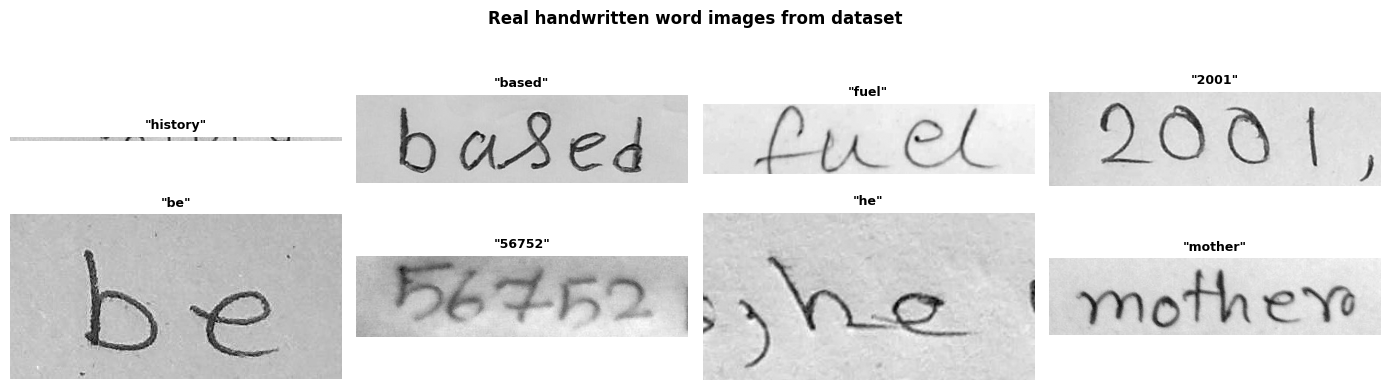

Train batches=2391  Val batches=266
Parameters : 52,006,123

   ICDAR HWD 2024 Word Level — Training from Scratch


Epoch  1/30: 100%|███████████████████████████████████████████████████████| 2391/2391 [03:43<00:00, 10.71it/s, cacc=100.0%, loss=0.0107, lr=5.0e-04, wacc=100.0%]



Epoch  1/30 | Train loss=0.3049 WAcc=87.7% CAcc=90.6% | Val loss=3.8937 WAcc=0.0% CAcc=0.0%


Epoch  2/30: 100%|███████████████████████████████████████████████████████| 2391/2391 [03:26<00:00, 11.55it/s, cacc=100.0%, loss=0.0120, lr=5.0e-04, wacc=100.0%]



Epoch  2/30 | Train loss=0.0123 WAcc=99.6% CAcc=99.9% | Val loss=4.1908 WAcc=0.0% CAcc=0.1%


...


Epoch  5/30 | Train loss=0.0101 WAcc=99.7% CAcc=99.9% | Val loss=4.8523 WAcc=0.0% CAcc=0.1%


Epoch  6/30: 100%|███████████████████████████████████████████████████████| 2391/2391 [03:22<00:00, 11.80it/s, cacc=100.0%, loss=0.0088, lr=4.7e-04, wacc=100.0%]



Epoch  6/30 | Train loss=0.0100 WAcc=99.7% CAcc=99.9% | Val loss=3.3282 WAcc=0.0% CAcc=0.1%


Epoch  7/30: 100%|███████████████████████████████████████████████████████| 2391/2391 [03:23<00:00, 11.78it/s, cacc=100.0%, loss=0.0156, lr=4.5e-04, wacc=100.0%]



Epoch  7/30 | Train loss=0.0099 WAcc=99.7% CAcc=99.9% | Val loss=3.6913 WAcc=0.0% CAcc=0.0%

Early stopping — no val WAcc improvement for 7 epochs.

Done. Best val WAcc=0.00%  loss=3.3282


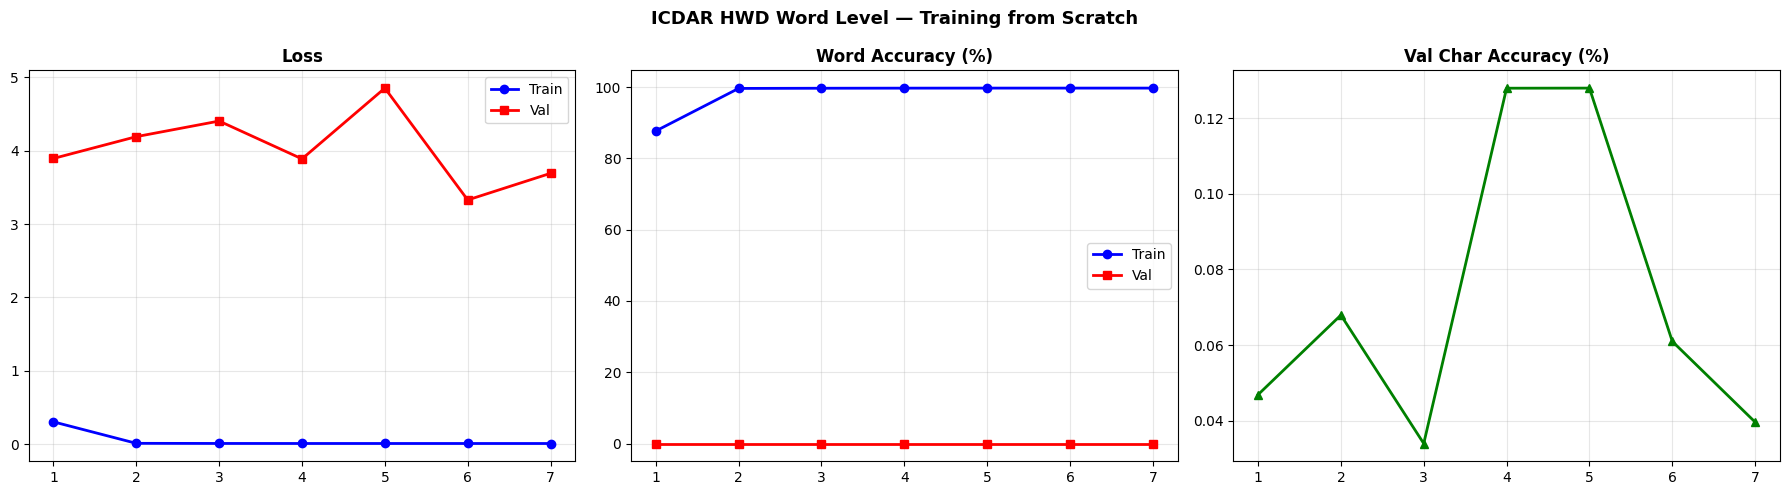

FileNotFoundError: [Errno 2] No such file or directory: '/home/mca/Shweta/handwritten text detection/saved_models/icdar_word_scratch/icdar_word.pth'

In [4]:
# ============================================================
#  ICDAR HWD 2024 — Word Level — Train from Scratch
#  GT format: image/39254_1.jpg\t13113
# ============================================================

import os, re, random, torch, torch.nn as nn, torch.optim as optim
import torch.nn.functional as F
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from tqdm import tqdm
import matplotlib.pyplot as plt

# ── DEVICE ───────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# ── CONFIG ───────────────────────────────────────────────────
# Root folder that contains the 'image/' subfolder and gt .txt file
DATASET_ROOT   = '/home/mca/Shweta/handwritten text detection/dataset/Word_Level_English_Training_Set/Word_Level_Training_Set'
GT_FILE        = 'train.txt'     # ← filename of your ground truth txt
SAVE_DIR       = '/home/mca/Shweta/handwritten text detection/saved_models/icdar_word_scratch'

BATCH_SIZE       = 32
NUM_EPOCHS       = 30
LEARNING_RATE    = 5e-4
NUM_WORKERS      = 4
MAX_LABEL_LEN    = 25
IMG_H, IMG_W     = 32, 100
NUM_CLASSES      = 99
NUM_GATED_LAYERS = 6
VAL_SPLIT  = 0.1   # 10%

PATIENCE         = 7

os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save dir : {SAVE_DIR}")

# ── VOCABULARY ───────────────────────────────────────────────
CHARS = ' !"#$%&\'()*+,-./0123456789:;<=>?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[\\]^_`abcdefghijklmnopqrstuvwxyz{|}~'
GO_IDX, EOS_IDX, PAD_IDX, UNK_IDX = 0, 1, 2, 3
CHAR_TO_IDX = {c: i+4 for i, c in enumerate(CHARS)}
IDX_TO_CHAR = {v: k for k, v in CHAR_TO_IDX.items()}
IDX_TO_CHAR.update({0:'<GO>', 1:'<EOS>', 2:'<PAD>', 3:'<UNK>'})

def encode_label(text, max_len):
    tokens = [GO_IDX]
    for c in text[:max_len]:
        tokens.append(CHAR_TO_IDX.get(c, UNK_IDX))
    tokens.append(EOS_IDX)
    while len(tokens) < max_len + 2:
        tokens.append(PAD_IDX)
    return torch.tensor(tokens[:max_len+2], dtype=torch.long)

def decode_label(tensor):
    chars = []
    for idx in tensor.tolist():
        if idx == EOS_IDX: break
        if idx not in (GO_IDX, PAD_IDX, UNK_IDX):
            chars.append(IDX_TO_CHAR.get(idx, ''))
    return ''.join(chars)

print(f"Vocab : {len(CHARS)+4} classes")
print(f"Encode test : '{decode_label(encode_label('Hello', MAX_LABEL_LEN))}'")

# ── DATASET ──────────────────────────────────────────────────
def get_transforms(imgH, imgW, augment=False):
    ops = [transforms.Grayscale(1), transforms.Resize((imgH, imgW))]
    if augment:
        ops += [
            transforms.RandomAffine(degrees=8, translate=(0.05,0.05),
                                    scale=(0.85,1.15), shear=8),
            transforms.ColorJitter(brightness=0.5, contrast=0.5),
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1,1.0)),
        ]
    ops += [transforms.ToTensor(), transforms.Normalize([0.5],[0.5])]
    return transforms.Compose(ops)


def load_gt_file(gt_path, dataset_root, max_label_len):
    """
    Parse the tab-separated ground truth file.

    Format per line:
        image/39254_1.jpg\t13113
        image/39254_2.jpg\tAnd

    Returns list of (absolute_image_path, label_string).
    Skips lines where:
      - separator is missing
      - label is empty or longer than max_label_len
      - image file does not exist on disk
    """
    samples  = []
    skipped  = 0
    total    = 0

    with open(gt_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.rstrip('\n')
            if '\t' not in line:
                skipped += 1
                continue

            rel_path, label = line.split('\t', 1)
            label    = label.strip()
            total   += 1

            # Skip bad labels
            if not label or len(label) > max_label_len:
                skipped += 1
                continue

            # Build absolute path
            abs_path = os.path.join(dataset_root, rel_path)
            if not os.path.exists(abs_path):
                skipped += 1
                continue

            samples.append((abs_path, label))

    print(f"[GT File] Total lines={total}  "
          f"Valid={len(samples)}  Skipped={skipped}")
    return samples


class ICDARWordLevelDataset(Dataset):
    """
    ICDAR HWD 2024 — proper word-level dataset.

    GT file format (tab separated):
        image/39254_1.jpg    13113
        image/39254_2.jpg    And
        image/39254_3.jpg    in

    Each line = one word image + its ground truth label.
    Images are real handwritten word crops — no rendering needed.
    """

    def __init__(self, samples, max_label_len=25,
                 imgH=32, imgW=100, augment=False):
        self.samples       = samples          # list of (abs_img_path, label)
        self.max_label_len = max_label_len
        self.transform     = get_transforms(imgH, imgW, augment)

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            image = Image.new('RGB', (IMG_W, IMG_H), (255, 255, 255))
        image   = self.transform(image)
        encoded = encode_label(label, self.max_label_len)
        return image, encoded, label


# REMOVE make_train_val_test_split and REPLACE with:
def make_train_val_split(all_samples, val_fraction):
    samples = all_samples.copy()
    random.seed(42)
    random.shuffle(samples)
    n_val   = max(1, int(len(samples) * val_fraction))
    n_train = len(samples) - n_val
    print(f"Split → Train={n_train}  Val={n_val}")
    return samples[:n_train], samples[n_train:]


# ── MODEL ARCHITECTURE ───────────────────────────────────────
class LocalizationNetwork(nn.Module):
    def __init__(self, F, I_channel_num):
        super().__init__()
        self.F = F
        self.conv = nn.Sequential(
            nn.Conv2d(I_channel_num,64,3,1,1), nn.BatchNorm2d(64),  nn.ReLU(True), nn.MaxPool2d(2,2),
            nn.Conv2d(64,128,3,1,1),           nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2,2),
            nn.Conv2d(128,256,3,1,1),          nn.BatchNorm2d(256), nn.ReLU(True), nn.MaxPool2d(2,2),
            nn.Conv2d(256,512,3,1,1),          nn.BatchNorm2d(512), nn.ReLU(True), nn.AdaptiveAvgPool2d(1),
        )
        self.fc1 = nn.Linear(512, 256)
        self.fc2 = nn.Linear(256, F*2)
        x     = np.linspace(-1.0, 1.0, int(F/2))
        y_top = np.linspace(0.0, -1.0, num=int(F/2))
        y_bot = np.linspace(1.0,  0.0, num=int(F/2))
        bias  = np.concatenate([np.stack([x,y_top],1), np.stack([x,y_bot],1)], 0)
        self.fc2.bias.data   = torch.from_numpy(bias).float().view(-1)
        self.fc2.weight.data.fill_(0)

    def forward(self, x):
        x = self.conv(x).squeeze(-1).squeeze(-1)
        return self.fc2(F.relu(self.fc1(x))).view(-1, self.F, 2)


class GridGenerator(nn.Module):
    def __init__(self, F, I_r_size):
        super().__init__()
        self.F   = F
        self.eps = 1e-6
        h, w     = I_r_size
        P        = self._build_P(w, h)
        self.register_buffer('inv_delta_C', self._build_inv_delta_C(F).float())
        self.register_buffer('P_hat',       self._build_P_hat(F, P).float())

    def _C(self):
        x = np.linspace(-1.0, 1.0, int(self.F/2))
        return np.concatenate([np.stack([x,-np.ones(int(self.F/2))],1),
                                np.stack([x, np.ones(int(self.F/2))],1)], 0)

    def _build_P(self, w, h):
        gx = (np.arange(-w,w,2)+1.0)/w
        gy = (np.arange(-h,h,2)+1.0)/h
        return np.stack(np.meshgrid(gx,gy), axis=2).reshape(-1,2)

    def _build_inv_delta_C(self, F):
        C     = self._C()
        hat_C = np.zeros((F,F))
        for i in range(F):
            for j in range(F):
                r = np.linalg.norm(C[i]-C[j])
                hat_C[i,j] = r**2 * np.log(r+self.eps)
        delta_C = np.concatenate([
            np.concatenate([np.ones((F,1)), C, hat_C],1),
            np.concatenate([np.zeros((2,3)), C.T],    1),
            np.concatenate([np.zeros((1,3)), np.ones((1,F))],1),
        ], 0)
        return torch.tensor(np.linalg.inv(delta_C))

    def _build_P_hat(self, F, P):
        C      = self._C()
        n      = P.shape[0]
        P_diff = np.tile(P[:,None,:], (1,F,1)) - C[None,:,:]
        rbf    = np.linalg.norm(P_diff, axis=2)
        rbf    = rbf**2 * np.log(rbf+self.eps)
        return torch.tensor(np.concatenate([np.ones((n,1)), P, rbf], 1))

    def build_P_prime(self, batch_C_prime):
        B = batch_C_prime.size(0)
        z = torch.cat([batch_C_prime, torch.zeros(B,3,2,device=batch_C_prime.device)], 1)
        T = torch.bmm(self.inv_delta_C.expand(B,-1,-1), z)
        return torch.bmm(self.P_hat.expand(B,-1,-1), T)


class TPSSpatialTransformerNetwork(nn.Module):
    def __init__(self, F=20, I_size=(32,100), I_r_size=(32,100), I_channel_num=1):
        super().__init__()
        self.LocalizationNetwork = LocalizationNetwork(F, I_channel_num)
        self.GridGenerator       = GridGenerator(F, I_r_size)

    def forward(self, batch_I):
        C_prime = self.LocalizationNetwork(batch_I)
        P_prime = self.GridGenerator.build_P_prime(C_prime)
        B       = P_prime.size(0)
        return F.grid_sample(batch_I, P_prime.reshape([B,32,100,2]),
                             padding_mode='border', align_corners=True)


class BasicBlock(nn.Module):
    def __init__(self, inplanes, planes, stride=1, downsample=None, dropout=0.1):
        super().__init__()
        self.conv1      = nn.Conv2d(inplanes, planes, 3, stride=stride, padding=1, bias=False)
        self.bn1        = nn.BatchNorm2d(planes)
        self.conv2      = nn.Conv2d(planes, planes, 3, padding=1, bias=False)
        self.bn2        = nn.BatchNorm2d(planes)
        self.relu       = nn.ReLU(inplace=True)
        self.dropout    = nn.Dropout2d(p=dropout)
        self.downsample = downsample

    def forward(self, x):
        res = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        if self.downsample: res = self.downsample(x)
        return self.relu(out + res)


class ResNet(nn.Module):
    def __init__(self, input_channel, output_channel, block, layers):
        super().__init__()
        ocb           = [output_channel//4, output_channel//2, output_channel, output_channel]
        self.inplanes = output_channel//8
        self.conv0_1  = nn.Conv2d(input_channel,      output_channel//16, 3,1,1, bias=False)
        self.bn0_1    = nn.BatchNorm2d(output_channel//16)
        self.conv0_2  = nn.Conv2d(output_channel//16, self.inplanes,      3,1,1, bias=False)
        self.bn0_2    = nn.BatchNorm2d(self.inplanes)
        self.relu     = nn.ReLU(inplace=True)
        self.maxpool1 = nn.MaxPool2d(2,2)
        self.layer1   = self._make_layer(block, ocb[0], layers[0])
        self.conv1    = nn.Conv2d(ocb[0], ocb[0], 3,1,1, bias=False); self.bn1 = nn.BatchNorm2d(ocb[0])
        self.maxpool2 = nn.MaxPool2d(2,2)
        self.layer2   = self._make_layer(block, ocb[1], layers[1])
        self.conv2    = nn.Conv2d(ocb[1], ocb[1], 3,1,1, bias=False); self.bn2 = nn.BatchNorm2d(ocb[1])
        self.maxpool3 = nn.MaxPool2d((2,1),(2,1))
        self.layer3   = self._make_layer(block, ocb[2], layers[2])
        self.conv3    = nn.Conv2d(ocb[2], ocb[2], 3,1,1, bias=False); self.bn3 = nn.BatchNorm2d(ocb[2])
        self.layer4   = self._make_layer(block, ocb[3], layers[3])
        self.conv4_1  = nn.Conv2d(ocb[3], ocb[3], 2,1,0,         bias=False); self.bn4_1 = nn.BatchNorm2d(ocb[3])
        self.conv4_2  = nn.Conv2d(ocb[3], ocb[3], 2,(1,1),(1,0), bias=False); self.bn4_2 = nn.BatchNorm2d(ocb[3])

    def _make_layer(self, block, planes, blocks, stride=1):
        ds = None
        if stride != 1 or self.inplanes != planes:
            ds = nn.Sequential(nn.Conv2d(self.inplanes, planes, 1, stride, bias=False),
                               nn.BatchNorm2d(planes))
        lst = [block(self.inplanes, planes, stride, ds)]
        self.inplanes = planes
        for _ in range(1, blocks): lst.append(block(self.inplanes, planes))
        return nn.Sequential(*lst)

    def forward(self, x):
        x = self.relu(self.bn0_1(self.conv0_1(x)))
        x = self.relu(self.bn0_2(self.conv0_2(x)))
        x = self.maxpool1(x);  x = self.layer1(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool2(x);  x = self.layer2(x)
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.maxpool3(x);  x = self.layer3(x)
        x = self.relu(self.bn3(self.conv3(x))); x = self.layer4(x)
        x = self.relu(self.bn4_1(self.conv4_1(x)))
        x = self.relu(self.bn4_2(self.conv4_2(x)))
        return x


class ResNet_FeatureExtractor(nn.Module):
    def __init__(self, ic, oc=512):
        super().__init__()
        self.ConvNet = ResNet(ic, oc, BasicBlock, [1,2,5,3])
    def forward(self, x): return self.ConvNet(x)


class GatedConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, dilation=1, dropout=0.15):
        super().__init__()
        pad = (kernel_size-1)*dilation//2
        self.conv_gate  = nn.Conv1d(in_ch, out_ch, kernel_size, padding=pad, dilation=dilation)
        self.conv_value = nn.Conv1d(in_ch, out_ch, kernel_size, padding=pad, dilation=dilation)
        self.bn_gate    = nn.BatchNorm1d(out_ch)
        self.bn_value   = nn.BatchNorm1d(out_ch)
        self.layer_norm = nn.LayerNorm(out_ch)
        self.dropout    = nn.Dropout(p=dropout)
        self.residual   = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        nn.init.kaiming_normal_(self.conv_gate.weight)
        nn.init.kaiming_normal_(self.conv_value.weight)

    def forward(self, x):
        gate  = torch.sigmoid(self.bn_gate(self.conv_gate(x)))
        value = torch.tanh(self.bn_value(self.conv_value(x)))
        out   = self.dropout(gate * value) + self.residual(x)
        return self.layer_norm(out.permute(0,2,1)).permute(0,2,1)


class GatedCNNSequenceModule(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=6, dropout=0.15):
        super().__init__()
        dilations = [1,2,4,8,16,8,4,1]
        lst, in_ch = [], input_size
        for i in range(num_layers):
            lst.append(GatedConv1d(in_ch, hidden_size, 3, dilations[i%len(dilations)], dropout))
            in_ch = hidden_size
        self.gated_layers   = nn.Sequential(*lst)
        self.output_dropout = nn.Dropout(p=dropout)

    def forward(self, x):
        x = x.permute(0,2,1)
        x = self.output_dropout(self.gated_layers(x))
        return x.permute(0,2,1)


class BidirectionalLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout=0.15):
        super().__init__()
        self.rnn     = nn.LSTM(input_size, hidden_size, bidirectional=True, batch_first=True)
        self.linear  = nn.Linear(hidden_size*2, output_size)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.linear(self.dropout(out))


class AttentionCell(nn.Module):
    def __init__(self, input_size, hidden_size, num_embeddings):
        super().__init__()
        self.i2h   = nn.Linear(input_size, hidden_size, bias=False)
        self.h2h   = nn.Linear(hidden_size, hidden_size)
        self.score = nn.Linear(hidden_size, 1, bias=False)
        self.rnn   = nn.LSTMCell(input_size+num_embeddings, hidden_size)

    def forward(self, prev_hidden, batch_H, char_onehot):
        e       = self.score(torch.tanh(self.i2h(batch_H) + self.h2h(prev_hidden[0]).unsqueeze(1)))
        alpha   = F.softmax(e, dim=1)
        context = torch.bmm(alpha.permute(0,2,1), batch_H).squeeze(1)
        return self.rnn(torch.cat([context, char_onehot], 1), prev_hidden), alpha


class Attention(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, dropout=0.15):
        super().__init__()
        self.attention_cell = AttentionCell(input_size, hidden_size, num_classes)
        self.hidden_size    = hidden_size
        self.num_classes    = num_classes
        self.generator      = nn.Linear(hidden_size, num_classes)
        self.dropout        = nn.Dropout(p=dropout)

    def _char_to_onehot(self, input_char, onehot_dim):
        b = input_char.size(0)
        onehot = torch.zeros(b, onehot_dim, device=input_char.device)
        onehot.scatter_(1, input_char.unsqueeze(1), 1)
        return onehot

    def forward(self, batch_H, text, is_train=True, batch_max_length=25):
        B         = batch_H.size(0)
        num_steps = batch_max_length + 1
        hiddens   = torch.zeros(B, num_steps, self.hidden_size, device=batch_H.device)
        hidden    = (torch.zeros(B, self.hidden_size, device=batch_H.device),
                     torch.zeros(B, self.hidden_size, device=batch_H.device))
        if is_train:
            for i in range(num_steps):
                oh = self._char_to_onehot(text[:,i], self.num_classes)
                hidden, _ = self.attention_cell(hidden, batch_H, oh)
                hiddens[:,i,:] = hidden[0]
            return self.generator(self.dropout(hiddens))
        else:
            targets = torch.zeros(B, dtype=torch.long, device=batch_H.device)
            probs   = torch.zeros(B, num_steps, self.num_classes, device=batch_H.device)
            for i in range(num_steps):
                oh = self._char_to_onehot(targets, self.num_classes)
                hidden, _ = self.attention_cell(hidden, batch_H, oh)
                step = self.generator(hidden[0])
                probs[:,i,:] = step
                targets = step.argmax(1)
            return probs


class HybridTextRecognizer(nn.Module):
    def __init__(self, num_classes, input_channel=1, imgH=32, imgW=100,
                 hidden_size=256, batch_max_length=25, num_fiducial=20,
                 num_gated_layers=6, dropout=0.15):
        super().__init__()
        self.batch_max_length = batch_max_length
        self.num_classes      = num_classes
        self.Transformation   = TPSSpatialTransformerNetwork(
            F=num_fiducial, I_size=(imgH,imgW), I_r_size=(imgH,imgW), I_channel_num=input_channel)
        self.FeatureExtraction = ResNet_FeatureExtractor(input_channel, 512)
        self.AdaptiveAvgPool   = nn.AdaptiveAvgPool2d((None,1))
        self.GatedCNN          = GatedCNNSequenceModule(512, hidden_size, num_gated_layers, dropout)
        self.SequenceModeling  = nn.Sequential(
            BidirectionalLSTM(hidden_size, hidden_size, hidden_size, dropout),
            BidirectionalLSTM(hidden_size, hidden_size, hidden_size, dropout),
        )
        self.Prediction = Attention(hidden_size, hidden_size, num_classes, dropout)
        for name, param in self.named_parameters():
            if 'bias' in name: nn.init.constant_(param, 0)
            elif param.dim() > 1:
                if 'rnn' in name or 'lstm' in name.lower(): nn.init.orthogonal_(param)
                else: nn.init.kaiming_normal_(param)

    def forward(self, x, text, is_train=True):
        x = self.Transformation(x)
        v = self.FeatureExtraction(x)
        v = self.AdaptiveAvgPool(v.permute(0,3,1,2)).squeeze(3)
        g = self.GatedCNN(v)
        c = self.SequenceModeling(g)
        return self.Prediction(c.contiguous(), text, is_train, self.batch_max_length)

print("Model defined.")

# ── LOAD GT & SPLIT ──────────────────────────────────────────
gt_path     = os.path.join(DATASET_ROOT, GT_FILE)
all_samples = load_gt_file(gt_path, DATASET_ROOT, MAX_LABEL_LEN)

# Preview 3 entries so you can confirm paths resolve correctly
print("\nSample entries:")
for p, l in all_samples[:3]:
    exists = '✓' if os.path.exists(p) else '✗ MISSING'
    print(f"  [{exists}]  {p}  →  '{l}'")

train_samples, val_samples = make_train_val_split(all_samples, VAL_SPLIT)

train_ds = ICDARWordLevelDataset(train_samples, MAX_LABEL_LEN, IMG_H, IMG_W, augment=True)
val_ds   = ICDARWordLevelDataset(val_samples,   MAX_LABEL_LEN, IMG_H, IMG_W, augment=False)

# ── PREVIEW REAL IMAGES ──────────────────────────────────────
print("\nPreviewing real word images...")
fig, axes = plt.subplots(2, 4, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    if i >= len(val_ds): ax.axis('off'); continue
    img_path, label = val_ds.samples[i]
    try:
        img = Image.open(img_path).convert('L')
    except Exception:
        img = Image.new('L', (IMG_W, IMG_H), 255)
    ax.imshow(np.array(img), cmap='gray')
    ax.set_title(f'"{label}"', fontsize=9, fontweight='bold')
    ax.axis('off')
plt.suptitle('Real handwritten word images from dataset', fontweight='bold')
plt.tight_layout(); plt.show()

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)
print(f"Train batches={len(train_loader)}  Val batches={len(val_loader)}")

# ── MODEL, LOSS, OPTIMIZER ───────────────────────────────────
model = HybridTextRecognizer(
    num_classes=NUM_CLASSES, num_gated_layers=NUM_GATED_LAYERS,
    batch_max_length=MAX_LABEL_LEN,
).to(device)
print(f"Parameters : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

# ── HELPERS ──────────────────────────────────────────────────
def compute_metrics(logits, labels):
    preds = logits.argmax(dim=-1)
    word_ok = total_chars = correct_chars = 0
    for pred_seq, gt_seq in zip(preds, labels):
        pred_str = decode_label(pred_seq)
        gt_str   = decode_label(gt_seq)
        if pred_str == gt_str: word_ok += 1
        for pc, gc in zip(pred_str, gt_str):
            total_chars += 1; correct_chars += (pc == gc)
        total_chars += max(0, len(gt_str) - len(pred_str))
    n = len(labels)
    return word_ok/n, (correct_chars/total_chars if total_chars > 0 else 0.0)


def run_validation(model, loader, criterion, device):
    model.eval()
    tl = tw = tc = n = 0
    with torch.no_grad():
        for images, labels, _ in loader:
            images, labels = images.to(device), labels.to(device)
            logits     = model(images, labels, is_train=False)
            labels_aln = labels[:, :logits.size(1)].contiguous()
            loss       = criterion(logits.view(-1, NUM_CLASSES), labels_aln.view(-1))
            wa, ca     = compute_metrics(logits.cpu(), labels.cpu())
            tl += loss.item(); tw += wa; tc += ca; n += 1
    return tl/n, tw/n, tc/n

# ── TRAINING LOOP ────────────────────────────────────────────
history = {'epoch':[], 'train_loss':[], 'val_loss':[],
           'train_wacc':[], 'val_wacc':[], 'val_cacc':[], 'lr':[]}
best_val_wacc = 0.0
best_val_loss = float('inf')
no_improve    = 0

print("\n" + "="*65)
print("   ICDAR HWD 2024 Word Level — Training from Scratch")
print("="*65)

for epoch in range(NUM_EPOCHS):
    model.train()
    ep_loss = ep_wacc = ep_cacc = n = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:>2}/{NUM_EPOCHS}", leave=True)
    for images, labels, _ in pbar:
        images, labels = images.to(device), labels.to(device)
        logits     = model(images, labels, is_train=True)
        labels_aln = labels[:, :logits.size(1)].contiguous()
        loss       = criterion(logits.view(-1, NUM_CLASSES), labels_aln.view(-1))

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        wa, ca   = compute_metrics(logits.detach().cpu(), labels.cpu())
        ep_loss += loss.item(); ep_wacc += wa; ep_cacc += ca; n += 1

        pbar.set_postfix(loss=f'{loss.item():.4f}',
                         wacc=f'{wa*100:.1f}%',
                         cacc=f'{ca*100:.1f}%',
                         lr=f'{optimizer.param_groups[0]["lr"]:.1e}')

    scheduler.step()
    val_loss, val_wacc, val_cacc = run_validation(model, val_loader, criterion, device)

    avg_loss = ep_loss/n; avg_wacc = ep_wacc/n; avg_cacc = ep_cacc/n
    cur_lr   = optimizer.param_groups[0]['lr']

    history['epoch'].append(epoch+1)
    history['train_loss'].append(avg_loss); history['val_loss'].append(val_loss)
    history['train_wacc'].append(avg_wacc); history['val_wacc'].append(val_wacc)
    history['val_cacc'].append(val_cacc);   history['lr'].append(cur_lr)

    torch.save(model.state_dict(), os.path.join(SAVE_DIR, f'epoch_{epoch+1}.pth'))

    tag = ''
    if val_wacc > best_val_wacc:
        best_val_wacc = val_wacc
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, 'icdar_word.pth'))
        tag = '  ← best'; no_improve = 0
    else:
        no_improve += 1

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, 'best_loss.pth'))

    print(f"\nEpoch {epoch+1:>2}/{NUM_EPOCHS} | "
          f"Train loss={avg_loss:.4f} WAcc={avg_wacc*100:.1f}% CAcc={avg_cacc*100:.1f}% | "
          f"Val loss={val_loss:.4f} WAcc={val_wacc*100:.1f}% CAcc={val_cacc*100:.1f}%{tag}")

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping — no val WAcc improvement for {PATIENCE} epochs.")
        break

print(f"\nDone. Best val WAcc={best_val_wacc*100:.2f}%  loss={best_val_loss:.4f}")

# ── TRAINING CURVES ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(history['epoch'], history['train_loss'], 'b-o', label='Train', lw=2)
axes[0].plot(history['epoch'], history['val_loss'],   'r-s', label='Val',   lw=2)
axes[0].set_title('Loss', fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['epoch'], [w*100 for w in history['train_wacc']], 'b-o', label='Train', lw=2)
axes[1].plot(history['epoch'], [w*100 for w in history['val_wacc']],   'r-s', label='Val',   lw=2)
axes[1].set_title('Word Accuracy (%)', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(history['epoch'], [c*100 for c in history['val_cacc']], 'g-^', lw=2)
axes[2].set_title('Val Char Accuracy (%)', fontweight='bold'); axes[2].grid(alpha=0.3)

plt.suptitle('ICDAR HWD Word Level — Training from Scratch', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'curves.png'), dpi=150, bbox_inches='tight')
plt.show()






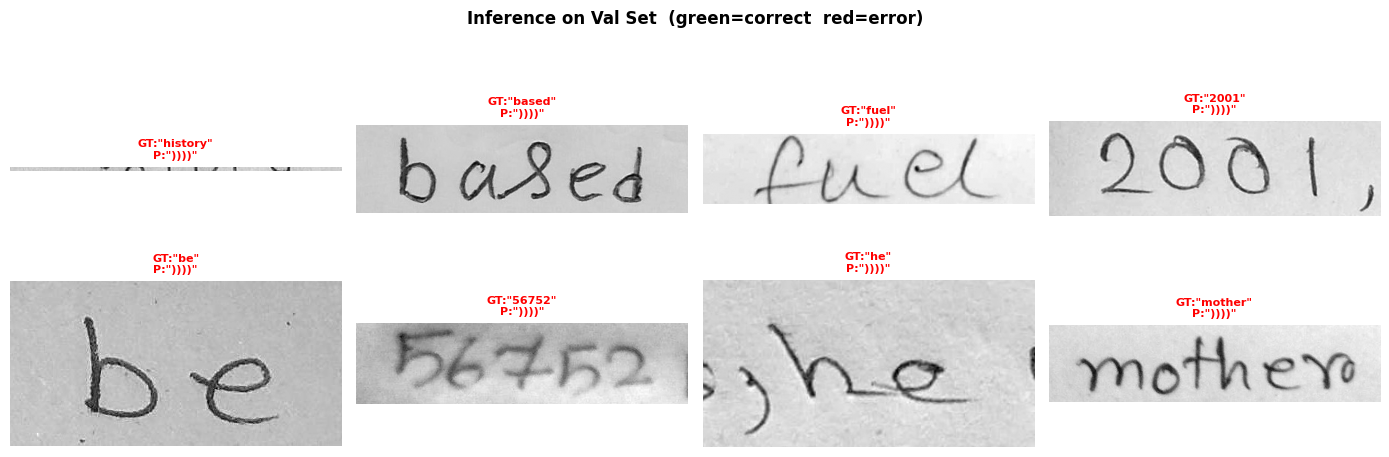

In [5]:
# ── INFERENCE PREVIEW ────────────────────────────────────────
model.load_state_dict(torch.load(os.path.join(SAVE_DIR,'epoch_7.pth'), map_location=device))
model.eval()
tfm   = get_transforms(IMG_H, IMG_W, augment=False)
fig, axes = plt.subplots(2, 4, figsize=(14, 5))
for i, ax in enumerate(axes.flat):
    if i >= len(val_ds): ax.axis('off'); continue
    img_path, gt = val_ds.samples[i]
    try:
        inp = tfm(Image.open(img_path).convert('RGB')).unsqueeze(0).to(device)
    except Exception:
        ax.axis('off'); continue
    dummy = torch.zeros(1, MAX_LABEL_LEN+2, dtype=torch.long).to(device)
    with torch.no_grad():
        out = model(inp, dummy, is_train=False)
    pred  = decode_label(out.squeeze(0).argmax(dim=-1))
    color = 'green' if pred == gt else 'red'
    ax.imshow(np.array(Image.open(img_path).convert('L')), cmap='gray')
    ax.set_title(f'GT:"{gt}"\nP:"{pred}"', fontsize=8, color=color, fontweight='bold')
    ax.axis('off')
plt.suptitle('Inference on Val Set  (green=correct  red=error)', fontweight='bold')
plt.tight_layout(); plt.show()

Device : cuda
GPU    : NVIDIA RTX 5000 Ada Generation
VRAM   : 33.8 GB
NUM_CLASSES = 99
Loaded samples : 85020
Train = 76518
Val   = 8502
Parameters = 9230307


Epoch 1/30: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 2392/2392 [01:40<00:00, 23.73it/s, loss=2.5434]



Epoch 1
Train Loss : 2.7854
Val Loss   : 2.3099
Val WAcc   : 30.26%
Val CAcc   : 40.37%
BEST MODEL SAVED


Epoch 2/30: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 2392/2392 [01:37<00:00, 24.50it/s, loss=1.1332]



Epoch 2
Train Loss : 1.7798
Val Loss   : 1.4141
Val WAcc   : 58.20%
Val CAcc   : 78.79%
BEST MODEL SAVED


...


Epoch 28
Train Loss : 0.7882
Val Loss   : 0.8382
Val WAcc   : 95.79%
Val CAcc   : 98.36%
BEST MODEL SAVED


Epoch 29/30: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 2392/2392 [01:43<00:00, 23.13it/s, loss=0.7853]



Epoch 29
Train Loss : 0.7879
Val Loss   : 0.8404
Val WAcc   : 95.69%
Val CAcc   : 98.31%


Epoch 30/30: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 2392/2392 [01:39<00:00, 23.97it/s, loss=0.7795]



Epoch 30
Train Loss : 0.7879
Val Loss   : 0.8400
Val WAcc   : 95.74%
Val CAcc   : 98.31%

Training Complete
Best Val Accuracy : 95.79%


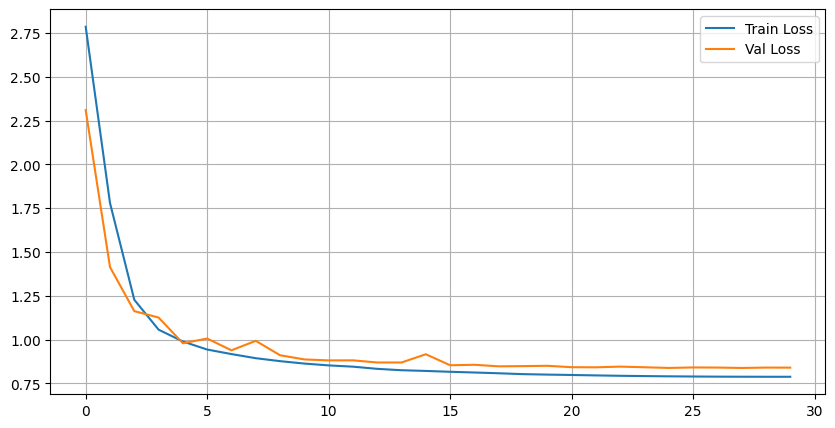

In [7]:
# ============================================================
# ICDAR HWD 2024 — WORD LEVEL OCR (CORRECTED VERSION)
# Stable Attention OCR Training
# ============================================================

import os
import random
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

from tqdm import tqdm
import matplotlib.pyplot as plt

# ============================================================
# DEVICE
# ============================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device : {device}")

if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# ============================================================
# CONFIG
# ============================================================

DATASET_ROOT = "/home/mca/Shweta/handwritten text detection/dataset/Word_Level_English_Training_Set/Word_Level_Training_Set"

GT_FILE = "train.txt"

SAVE_DIR = "/home/mca/Shweta/handwritten text detection/saved_models/icdar_word_corrected"

os.makedirs(SAVE_DIR, exist_ok=True)

BATCH_SIZE = 32
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
NUM_WORKERS = 4

MAX_LABEL_LEN = 25

IMG_H = 32
IMG_W = 160

VAL_SPLIT = 0.1

PATIENCE = 7

HIDDEN_SIZE = 256

# ============================================================
# VOCAB
# ============================================================

CHARS = ' !"#$%&\'()*+,-./0123456789:;<=>?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[\\]^_`abcdefghijklmnopqrstuvwxyz{|}~'

GO_IDX  = 0
EOS_IDX = 1
PAD_IDX = 2
UNK_IDX = 3

CHAR_TO_IDX = {c: i + 4 for i, c in enumerate(CHARS)}
IDX_TO_CHAR = {v: k for k, v in CHAR_TO_IDX.items()}

IDX_TO_CHAR.update({
    GO_IDX: "<GO>",
    EOS_IDX: "<EOS>",
    PAD_IDX: "<PAD>",
    UNK_IDX: "<UNK>"
})

NUM_CLASSES = len(CHARS) + 4

print("NUM_CLASSES =", NUM_CLASSES)

# ============================================================
# LABEL ENCODING
# ============================================================

def encode_label(text, max_len):

    tokens = [GO_IDX]

    for c in text[:max_len]:
        tokens.append(CHAR_TO_IDX.get(c, UNK_IDX))

    tokens.append(EOS_IDX)

    while len(tokens) < max_len + 2:
        tokens.append(PAD_IDX)

    return torch.tensor(tokens[:max_len+2], dtype=torch.long)


def decode_label(tensor):

    chars = []

    for idx in tensor.tolist():

        if idx in [EOS_IDX, PAD_IDX]:
            break

        if idx in [GO_IDX, UNK_IDX]:
            continue

        chars.append(IDX_TO_CHAR.get(idx, ""))

    return "".join(chars)

# ============================================================
# TRANSFORMS
# ============================================================

def get_transforms(imgH, imgW, augment=False):

    ops = [
        transforms.Grayscale(1),
        transforms.Resize((imgH, imgW))
    ]

    if augment:
        ops += [
            transforms.RandomAffine(
                degrees=2,
                translate=(0.02, 0.02),
                scale=(0.95, 1.05),
                shear=2
            )
        ]

    ops += [
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ]

    return transforms.Compose(ops)

# ============================================================
# DATASET
# ============================================================

def load_gt_file(gt_path, dataset_root, max_label_len):

    samples = []

    with open(gt_path, 'r', encoding='utf-8') as f:

        for line in f:

            line = line.rstrip('\n')

            if '\t' not in line:
                continue

            rel_path, label = line.split('\t', 1)

            label = label.strip()

            if len(label) == 0:
                continue

            if len(label) > max_label_len:
                continue

            abs_path = os.path.join(dataset_root, rel_path)

            if not os.path.exists(abs_path):
                continue

            samples.append((abs_path, label))

    print(f"Loaded samples : {len(samples)}")

    return samples


class ICDARWordDataset(Dataset):

    def __init__(
        self,
        samples,
        max_label_len=25,
        imgH=32,
        imgW=160,
        augment=False
    ):

        self.samples = samples
        self.max_label_len = max_label_len

        self.transform = get_transforms(
            imgH,
            imgW,
            augment
        )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        img_path, label = self.samples[idx]

        try:
            image = Image.open(img_path).convert("RGB")

        except:
            image = Image.new("RGB", (IMG_W, IMG_H), (255,255,255))

        image = self.transform(image)

        encoded = encode_label(
            label,
            self.max_label_len
        )

        return image, encoded, label

# ============================================================
# SPLIT
# ============================================================

def make_train_val_split(samples, val_fraction=0.1):

    samples = samples.copy()

    random.seed(42)

    random.shuffle(samples)

    n_val = int(len(samples) * val_fraction)

    val_samples = samples[:n_val]
    train_samples = samples[n_val:]

    print("Train =", len(train_samples))
    print("Val   =", len(val_samples))

    return train_samples, val_samples

# ============================================================
# CNN FEATURE EXTRACTOR
# ============================================================

class CNNFeatureExtractor(nn.Module):

    def __init__(self):

        super().__init__()

        self.cnn = nn.Sequential(

            nn.Conv2d(1, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.MaxPool2d((2,1), (2,1)),

            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.Conv2d(512, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.MaxPool2d((2,1), (2,1)),

            nn.Conv2d(512, 512, 2),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.cnn(x)

# ============================================================
# BiLSTM
# ============================================================

class BidirectionalLSTM(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size,
        output_size
    ):

        super().__init__()

        self.rnn = nn.LSTM(
            input_size,
            hidden_size,
            bidirectional=True,
            batch_first=True
        )

        self.linear = nn.Linear(
            hidden_size * 2,
            output_size
        )

    def forward(self, x):

        x, _ = self.rnn(x)

        x = self.linear(x)

        return x

# ============================================================
# ATTENTION
# ============================================================

class AttentionCell(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size,
        num_embeddings
    ):

        super().__init__()

        self.i2h = nn.Linear(
            input_size,
            hidden_size,
            bias=False
        )

        self.h2h = nn.Linear(
            hidden_size,
            hidden_size
        )

        self.score = nn.Linear(
            hidden_size,
            1,
            bias=False
        )

        self.rnn = nn.LSTMCell(
            input_size + num_embeddings,
            hidden_size
        )

    def forward(
        self,
        prev_hidden,
        batch_H,
        char_onehots
    ):

        batch_H_proj = self.i2h(batch_H)

        prev_hidden_proj = self.h2h(prev_hidden[0]).unsqueeze(1)

        e = self.score(
            torch.tanh(batch_H_proj + prev_hidden_proj)
        )

        alpha = F.softmax(e, dim=1)

        context = torch.bmm(
            alpha.permute(0,2,1),
            batch_H
        ).squeeze(1)

        concat_context = torch.cat(
            [context, char_onehots],
            dim=1
        )

        cur_hidden = self.rnn(
            concat_context,
            prev_hidden
        )

        return cur_hidden, alpha

# ============================================================
# ATTENTION DECODER
# ============================================================

class Attention(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size,
        num_classes
    ):

        super().__init__()

        self.attention_cell = AttentionCell(
            input_size,
            hidden_size,
            num_classes
        )

        self.hidden_size = hidden_size
        self.num_classes = num_classes

        self.generator = nn.Linear(
            hidden_size,
            num_classes
        )

    def _char_to_onehot(self, input_char):

        one_hot = torch.zeros(
            input_char.size(0),
            self.num_classes,
            device=input_char.device
        )

        one_hot.scatter_(1, input_char.unsqueeze(1), 1)

        return one_hot

    def forward(
        self,
        batch_H,
        text,
        is_train=True,
        batch_max_length=25
    ):

        batch_size = batch_H.size(0)

        num_steps = batch_max_length + 1

        hidden = (
            torch.zeros(batch_size, self.hidden_size, device=batch_H.device),
            torch.zeros(batch_size, self.hidden_size, device=batch_H.device)
        )

        output_hiddens = torch.zeros(
            batch_size,
            num_steps,
            self.hidden_size,
            device=batch_H.device
        )

        # ====================================================
        # TRAIN
        # ====================================================

        if is_train:

            for i in range(num_steps):

                char_onehots = self._char_to_onehot(text[:, i])

                hidden, alpha = self.attention_cell(
                    hidden,
                    batch_H,
                    char_onehots
                )

                output_hiddens[:, i, :] = hidden[0]

            probs = self.generator(output_hiddens)

        # ====================================================
        # INFERENCE
        # ====================================================

        else:

            targets = torch.LongTensor(
                batch_size
            ).fill_(GO_IDX).to(batch_H.device)

            probs = torch.zeros(
                batch_size,
                num_steps,
                self.num_classes,
                device=batch_H.device
            )

            for i in range(num_steps):

                char_onehots = self._char_to_onehot(targets)

                hidden, alpha = self.attention_cell(
                    hidden,
                    batch_H,
                    char_onehots
                )

                probs_step = self.generator(hidden[0])

                probs[:, i, :] = probs_step

                _, next_input = probs_step.max(1)

                targets = next_input

        return probs

# ============================================================
# FULL OCR MODEL
# ============================================================

class OCRModel(nn.Module):

    def __init__(self):

        super().__init__()

        # TPS REMOVED
        self.Transformation = nn.Identity()

        self.FeatureExtraction = CNNFeatureExtractor()

        self.AdaptiveAvgPool = nn.AdaptiveAvgPool2d((None,1))

        self.SequenceModeling = nn.Sequential(

            BidirectionalLSTM(
                512,
                HIDDEN_SIZE,
                HIDDEN_SIZE
            ),

            BidirectionalLSTM(
                HIDDEN_SIZE,
                HIDDEN_SIZE,
                HIDDEN_SIZE
            )
        )

        self.Prediction = Attention(
            HIDDEN_SIZE,
            HIDDEN_SIZE,
            NUM_CLASSES
        )

    def forward(
        self,
        images,
        text,
        is_train=True
    ):

        visual_feature = self.FeatureExtraction(images)

        visual_feature = self.AdaptiveAvgPool(
            visual_feature.permute(0,3,1,2)
        )

        visual_feature = visual_feature.squeeze(3)

        contextual_feature = self.SequenceModeling(
            visual_feature
        )

        prediction = self.Prediction(
            contextual_feature.contiguous(),
            text,
            is_train,
            MAX_LABEL_LEN
        )

        return prediction

# ============================================================
# LOAD DATA
# ============================================================

gt_path = os.path.join(
    DATASET_ROOT,
    GT_FILE
)

all_samples = load_gt_file(
    gt_path,
    DATASET_ROOT,
    MAX_LABEL_LEN
)

train_samples, val_samples = make_train_val_split(
    all_samples,
    VAL_SPLIT
)

train_ds = ICDARWordDataset(
    train_samples,
    MAX_LABEL_LEN,
    IMG_H,
    IMG_W,
    augment=True
)

val_ds = ICDARWordDataset(
    val_samples,
    MAX_LABEL_LEN,
    IMG_H,
    IMG_W,
    augment=False
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# ============================================================
# MODEL
# ============================================================

model = OCRModel().to(device)

print("Parameters =", sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
))

# ============================================================
# LOSS
# ============================================================

criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_IDX,
    label_smoothing=0.1
)

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS
)

# ============================================================
# METRICS
# ============================================================

def compute_metrics(logits, labels):

    preds = logits.argmax(dim=-1)

    total_words = 0
    correct_words = 0

    total_chars = 0
    correct_chars = 0

    for pred_seq, gt_seq in zip(preds, labels):

        pred_str = decode_label(pred_seq)
        gt_str = decode_label(gt_seq)

        total_words += 1

        if pred_str == gt_str:
            correct_words += 1

        for p, g in zip(pred_str, gt_str):

            total_chars += 1

            if p == g:
                correct_chars += 1

    word_acc = correct_words / total_words

    char_acc = correct_chars / max(total_chars, 1)

    return word_acc, char_acc

# ============================================================
# VALIDATION
# ============================================================

def run_validation():

    model.eval()

    total_loss = 0

    total_wacc = 0
    total_cacc = 0

    n = 0

    with torch.no_grad():

        for images, labels, _ in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            dummy_text = torch.zeros(
                labels.size(0),
                MAX_LABEL_LEN + 1,
                dtype=torch.long,
                device=device
            )

            logits = model(
                images,
                dummy_text,
                is_train=False
            )

            target = labels[:, 1:]

            loss = criterion(
                logits.reshape(-1, NUM_CLASSES),
                target.reshape(-1)
            )

            wacc, cacc = compute_metrics(
                logits.cpu(),
                labels.cpu()
            )

            total_loss += loss.item()

            total_wacc += wacc
            total_cacc += cacc

            n += 1

    return (
        total_loss / n,
        total_wacc / n,
        total_cacc / n
    )

# ============================================================
# TRAIN
# ============================================================

best_val_acc = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "val_wacc": []
}

for epoch in range(NUM_EPOCHS):

    model.train()

    running_loss = 0

    pbar = tqdm(train_loader)

    for images, labels, _ in pbar:

        images = images.to(device)
        labels = labels.to(device)

        logits = model(
            images,
            labels[:, :-1],
            is_train=True
        )

        target = labels[:, 1:]

        loss = criterion(
            logits.reshape(-1, NUM_CLASSES),
            target.reshape(-1)
        )

        optimizer.zero_grad()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            5.0
        )

        optimizer.step()

        running_loss += loss.item()

        pbar.set_description(
            f"Epoch {epoch+1}/{NUM_EPOCHS}"
        )

        pbar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    scheduler.step()

    train_loss = running_loss / len(train_loader)

    val_loss, val_wacc, val_cacc = run_validation()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_wacc"].append(val_wacc)

    print()

    print(f"Epoch {epoch+1}")
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val WAcc   : {val_wacc*100:.2f}%")
    print(f"Val CAcc   : {val_cacc*100:.2f}%")

    torch.save(
        model.state_dict(),
        os.path.join(SAVE_DIR, "last.pth")
    )

    if val_wacc > best_val_acc:

        best_val_acc = val_wacc

        torch.save(
            model.state_dict(),
            os.path.join(SAVE_DIR, "best.pth")
        )

        print("BEST MODEL SAVED")

print()

print("Training Complete")

print(f"Best Val Accuracy : {best_val_acc*100:.2f}%")

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")

plt.legend()

plt.grid(True)

plt.savefig(
    os.path.join(SAVE_DIR, "loss_curve.png")
)

plt.show()

In [1]:
# ============================================================
# VALIDATION EVALUATION SCRIPT
# Calculates:
# 1. Word Accuracy
# 2. Character Accuracy
# 3. CER (Character Error Rate)
# 4. WER (Word Error Rate)
#
# Uses VALIDATION SPLIT from TRAIN DATA
# ============================================================

import os
import random
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

from tqdm import tqdm

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device : {device}")

if torch.cuda.is_available():
    print(f"GPU : {torch.cuda.get_device_name(0)}")

# ============================================================
# PATHS
# ============================================================

DATASET_ROOT = "/home/mca/Shweta/handwritten text detection/dataset/Word_Level_English_Training_Set/Word_Level_Training_Set"

GT_FILE = "train.txt"

MODEL_PATH = "/home/mca/Shweta/handwritten text detection/saved_models/icdar_word_corrected/best.pth"

# ============================================================
# CONFIG
# ============================================================

IMG_H = 32
IMG_W = 160

MAX_LABEL_LEN = 25

HIDDEN_SIZE = 256

VAL_SPLIT = 0.1

BATCH_SIZE = 32

NUM_WORKERS = 4

# ============================================================
# VOCAB
# ============================================================

CHARS = ' !"#$%&\'()*+,-./0123456789:;<=>?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[\\]^_`abcdefghijklmnopqrstuvwxyz{|}~'

GO_IDX  = 0
EOS_IDX = 1
PAD_IDX = 2
UNK_IDX = 3

CHAR_TO_IDX = {c: i + 4 for i, c in enumerate(CHARS)}

IDX_TO_CHAR = {v: k for k, v in CHAR_TO_IDX.items()}

IDX_TO_CHAR.update({
    GO_IDX: "<GO>",
    EOS_IDX: "<EOS>",
    PAD_IDX: "<PAD>",
    UNK_IDX: "<UNK>"
})

NUM_CLASSES = len(CHARS) + 4

# ============================================================
# LABEL ENCODING / DECODING
# ============================================================

def encode_label(text, max_len):

    tokens = [GO_IDX]

    for c in text[:max_len]:
        tokens.append(CHAR_TO_IDX.get(c, UNK_IDX))

    tokens.append(EOS_IDX)

    while len(tokens) < max_len + 2:
        tokens.append(PAD_IDX)

    return torch.tensor(tokens[:max_len+2], dtype=torch.long)


def decode_label(tensor):

    chars = []

    for idx in tensor.tolist():

        if idx in [EOS_IDX, PAD_IDX]:
            break

        if idx in [GO_IDX, UNK_IDX]:
            continue

        chars.append(IDX_TO_CHAR.get(idx, ""))

    return "".join(chars)

# ============================================================
# TRANSFORMS
# ============================================================

transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((IMG_H, IMG_W)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# ============================================================
# LOAD GT FILE
# ============================================================

def load_gt_file(gt_path, dataset_root, max_label_len):

    samples = []

    with open(gt_path, 'r', encoding='utf-8') as f:

        for line in f:

            line = line.rstrip('\n')

            if '\t' not in line:
                continue

            rel_path, label = line.split('\t', 1)

            label = label.strip()

            if len(label) == 0:
                continue

            if len(label) > max_label_len:
                continue

            abs_path = os.path.join(dataset_root, rel_path)

            if not os.path.exists(abs_path):
                continue

            samples.append((abs_path, label))

    print(f"Loaded samples : {len(samples)}")

    return samples

# ============================================================
# TRAIN / VAL SPLIT
# ============================================================

def make_train_val_split(samples, val_fraction=0.1):

    samples = samples.copy()

    random.seed(42)

    random.shuffle(samples)

    n_val = int(len(samples) * val_fraction)

    val_samples = samples[:n_val]
    train_samples = samples[n_val:]

    print(f"Train Samples : {len(train_samples)}")
    print(f"Val Samples   : {len(val_samples)}")

    return train_samples, val_samples

# ============================================================
# DATASET
# ============================================================

class ICDARDataset(Dataset):

    def __init__(self, samples):

        self.samples = samples

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, idx):

        image_path, label = self.samples[idx]

        try:

            image = Image.open(image_path).convert("RGB")

        except:

            image = Image.new("RGB", (IMG_W, IMG_H), (255,255,255))

        image = transform(image)

        encoded = encode_label(label, MAX_LABEL_LEN)

        return image, encoded, label

# ============================================================
# CNN FEATURE EXTRACTOR
# ============================================================

class CNNFeatureExtractor(nn.Module):

    def __init__(self):

        super().__init__()

        self.cnn = nn.Sequential(

            nn.Conv2d(1, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.MaxPool2d((2,1), (2,1)),

            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.Conv2d(512, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.MaxPool2d((2,1), (2,1)),

            nn.Conv2d(512, 512, 2),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.cnn(x)

# ============================================================
# BiLSTM
# ============================================================

class BidirectionalLSTM(nn.Module):

    def __init__(self, input_size, hidden_size, output_size):

        super().__init__()

        self.rnn = nn.LSTM(
            input_size,
            hidden_size,
            bidirectional=True,
            batch_first=True
        )

        self.linear = nn.Linear(
            hidden_size * 2,
            output_size
        )

    def forward(self, x):

        x, _ = self.rnn(x)

        x = self.linear(x)

        return x

# ============================================================
# ATTENTION CELL
# ============================================================

class AttentionCell(nn.Module):

    def __init__(self, input_size, hidden_size, num_embeddings):

        super().__init__()

        self.i2h = nn.Linear(input_size, hidden_size, bias=False)

        self.h2h = nn.Linear(hidden_size, hidden_size)

        self.score = nn.Linear(hidden_size, 1, bias=False)

        self.rnn = nn.LSTMCell(
            input_size + num_embeddings,
            hidden_size
        )

    def forward(self, prev_hidden, batch_H, char_onehots):

        batch_H_proj = self.i2h(batch_H)

        prev_hidden_proj = self.h2h(prev_hidden[0]).unsqueeze(1)

        e = self.score(
            torch.tanh(batch_H_proj + prev_hidden_proj)
        )

        alpha = F.softmax(e, dim=1)

        context = torch.bmm(
            alpha.permute(0,2,1),
            batch_H
        ).squeeze(1)

        concat_context = torch.cat(
            [context, char_onehots],
            dim=1
        )

        cur_hidden = self.rnn(
            concat_context,
            prev_hidden
        )

        return cur_hidden, alpha

# ============================================================
# ATTENTION
# ============================================================

class Attention(nn.Module):

    def __init__(self, input_size, hidden_size, num_classes):

        super().__init__()

        self.attention_cell = AttentionCell(
            input_size,
            hidden_size,
            num_classes
        )

        self.hidden_size = hidden_size
        self.num_classes = num_classes

        self.generator = nn.Linear(
            hidden_size,
            num_classes
        )

    def _char_to_onehot(self, input_char):

        one_hot = torch.zeros(
            input_char.size(0),
            self.num_classes,
            device=input_char.device
        )

        one_hot.scatter_(1, input_char.unsqueeze(1), 1)

        return one_hot

    def forward(
        self,
        batch_H,
        text=None,
        is_train=False,
        batch_max_length=25
    ):

        batch_size = batch_H.size(0)

        num_steps = batch_max_length + 1

        hidden = (
            torch.zeros(batch_size, self.hidden_size, device=batch_H.device),
            torch.zeros(batch_size, self.hidden_size, device=batch_H.device)
        )

        targets = torch.LongTensor(batch_size).fill_(GO_IDX).to(batch_H.device)

        probs = torch.zeros(
            batch_size,
            num_steps,
            self.num_classes,
            device=batch_H.device
        )

        for i in range(num_steps):

            char_onehots = self._char_to_onehot(targets)

            hidden, alpha = self.attention_cell(
                hidden,
                batch_H,
                char_onehots
            )

            probs_step = self.generator(hidden[0])

            probs[:, i, :] = probs_step

            _, next_input = probs_step.max(1)

            targets = next_input

        return probs

# ============================================================
# OCR MODEL
# ============================================================

class OCRModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.FeatureExtraction = CNNFeatureExtractor()

        self.AdaptiveAvgPool = nn.AdaptiveAvgPool2d((None,1))

        self.SequenceModeling = nn.Sequential(

            BidirectionalLSTM(
                512,
                HIDDEN_SIZE,
                HIDDEN_SIZE
            ),

            BidirectionalLSTM(
                HIDDEN_SIZE,
                HIDDEN_SIZE,
                HIDDEN_SIZE
            )
        )

        self.Prediction = Attention(
            HIDDEN_SIZE,
            HIDDEN_SIZE,
            NUM_CLASSES
        )

    def forward(self, images):

        visual_feature = self.FeatureExtraction(images)

        visual_feature = self.AdaptiveAvgPool(
            visual_feature.permute(0,3,1,2)
        )

        visual_feature = visual_feature.squeeze(3)

        contextual_feature = self.SequenceModeling(
            visual_feature
        )

        prediction = self.Prediction(
            contextual_feature.contiguous(),
            None,
            is_train=False,
            batch_max_length=MAX_LABEL_LEN
        )

        return prediction

# ============================================================
# LEVENSHTEIN DISTANCE
# ============================================================

def edit_distance(str1, str2):

    m = len(str1)
    n = len(str2)

    dp = [[0]*(n+1) for _ in range(m+1)]

    for i in range(m+1):
        dp[i][0] = i

    for j in range(n+1):
        dp[0][j] = j

    for i in range(1, m+1):

        for j in range(1, n+1):

            if str1[i-1] == str2[j-1]:

                dp[i][j] = dp[i-1][j-1]

            else:

                dp[i][j] = 1 + min(
                    dp[i-1][j],
                    dp[i][j-1],
                    dp[i-1][j-1]
                )

    return dp[m][n]

# ============================================================
# LOAD DATA
# ============================================================

gt_path = os.path.join(DATASET_ROOT, GT_FILE)

all_samples = load_gt_file(
    gt_path,
    DATASET_ROOT,
    MAX_LABEL_LEN
)

train_samples, val_samples = make_train_val_split(
    all_samples,
    VAL_SPLIT
)

val_dataset = ICDARDataset(val_samples)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

# ============================================================
# LOAD MODEL
# ============================================================

model = OCRModel().to(device)

model.load_state_dict(
    torch.load(MODEL_PATH, map_location=device)
)

model.eval()

print("\nModel Loaded Successfully")

# ============================================================
# EVALUATION
# ============================================================

total_words = 0
correct_words = 0

total_chars = 0
correct_chars = 0

total_edit_distance = 0

print("\nRunning Validation Evaluation...\n")

with torch.no_grad():

    for images, labels, gt_texts in tqdm(val_loader):

        images = images.to(device)

        logits = model(images)

        preds = logits.argmax(dim=-1)

        for pred_seq, gt_text in zip(preds, gt_texts):

            pred_text = decode_label(pred_seq.cpu())

            # =================================================
            # WORD ACCURACY
            # =================================================

            total_words += 1

            if pred_text == gt_text:
                correct_words += 1

            # =================================================
            # CHARACTER ACCURACY
            # =================================================

            for p, g in zip(pred_text, gt_text):

                total_chars += 1

                if p == g:
                    correct_chars += 1

            # =================================================
            # CER
            # =================================================

            total_edit_distance += edit_distance(
                pred_text,
                gt_text
            )

            # =================================================
            # OPTIONAL PREDICTION PRINT
            # =================================================

            # print(f"GT   : {gt_text}")
            # print(f"PRED : {pred_text}")
            # print()

# ============================================================
# FINAL METRICS
# ============================================================

word_acc = 100.0 * correct_words / total_words

char_acc = 100.0 * correct_chars / max(total_chars, 1)

cer = 100.0 * total_edit_distance / max(total_chars, 1)

wer = 100.0 * (total_words - correct_words) / total_words

# ============================================================
# RESULTS
# ============================================================

print("\n================================================")
print("VALIDATION RESULTS")
print("================================================")

print(f"Total Samples        : {total_words}")

print(f"\nWord Accuracy        : {word_acc:.2f}%")

print(f"Character Accuracy   : {char_acc:.2f}%")

print(f"\nCER                  : {cer:.2f}%")

print(f"WER                  : {wer:.2f}%")

print("================================================")

/home/mca/Shweta/handwritten text detection/sbenv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Device : cuda
GPU : NVIDIA RTX 5000 Ada Generation
Loaded samples : 85020
Train Samples : 76518
Val Samples   : 8502

Model Loaded Successfully

Running Validation Evaluation...



100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 266/266 [00:06<00:00, 43.82it/s]


VALIDATION RESULTS
Total Samples        : 8502

Word Accuracy        : 95.79%
Character Accuracy   : 98.35%

CER                  : 1.42%
WER                  : 4.21%


## 2 (gpt)

In [ ]:
# ============================================================
# ICDAR HWD 2024 — WORD LEVEL OCR (GPT‑2 PIPELINE)
# Swin + TPS + BiLSTM + GPT‑2 + LLRD + Agentic Verification
# ============================================================

import os
import random
import numpy as np
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

from tqdm import tqdm
import matplotlib.pyplot as plt
import timm
from transformers import GPT2LMHeadModel, GPT2Config
import Levenshtein
from jiwer import wer

# ============================================================
# DEVICE
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# ============================================================
# CONFIGURATION
# ============================================================
DATASET_ROOT = "/home/mca24-26/ocr/dataset/Word_Level_English_Training_Set/Word_Level_Training_Set"
GT_FILE = "train.txt"
SAVE_DIR = "/home/mca24-26/handwritten text detection/saved_models/icdar_gpt"
os.makedirs(SAVE_DIR, exist_ok=True)

BATCH_SIZE = 32               # Reduce if OOM
NUM_EPOCHS = 40
LEARNING_RATE = 5e-5
NUM_WORKERS = 4
MAX_LABEL_LEN = 25            # same as ICDAR
IMG_H = 64                    # Swin works better with slightly larger height
IMG_W = 256                   # Wider for better sequence
VAL_SPLIT = 0.1
PATIENCE = 8

D_MODEL = 768
BEAM_SIZE = 5                 # for final test

# ============================================================
# VOCABULARY (same as ICDAR)
# ============================================================
CHARS = ' !"#$%&\'()*+,-./0123456789:;<=>?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[\\]^_`abcdefghijklmnopqrstuvwxyz{|}~'
GO_IDX  = 0
EOS_IDX = 1
PAD_IDX = 2
UNK_IDX = 3

CHAR_TO_IDX = {c: i + 4 for i, c in enumerate(CHARS)}
IDX_TO_CHAR = {v: k for k, v in CHAR_TO_IDX.items()}
IDX_TO_CHAR.update({GO_IDX: "<GO>", EOS_IDX: "<EOS>", PAD_IDX: "<PAD>", UNK_IDX: "<UNK>"})

VOCAB_SIZE = len(CHARS) + 4   # 98
PAD_IDX = PAD_IDX
SOS_IDX = GO_IDX               # we use GO as start token
EOS_IDX = EOS_IDX

print("VOCAB SIZE =", VOCAB_SIZE)

# ============================================================
# LABEL ENCODING / DECODING (adapted for GPT‑2)
# ============================================================
def encode_label(text, max_len):
    tokens = [SOS_IDX]   # <GO>
    for c in text[:max_len]:
        tokens.append(CHAR_TO_IDX.get(c, UNK_IDX))
    tokens.append(EOS_IDX)
    while len(tokens) < max_len + 2:
        tokens.append(PAD_IDX)
    return torch.tensor(tokens[:max_len+2], dtype=torch.long)

def decode_label(tensor):
    chars = []
    for idx in tensor.tolist():
        if idx in [EOS_IDX, PAD_IDX]:
            break
        if idx in [SOS_IDX, UNK_IDX]:
            continue
        chars.append(IDX_TO_CHAR.get(idx, ""))
    return "".join(chars)

# ============================================================
# TRANSFORMS (RGB conversion for Swin)
# ============================================================
def get_transforms(imgH, imgW, augment=False):
    ops = [
        transforms.Resize((imgH, imgW)),
    ]
    if augment:
        ops += [
            transforms.RandomAffine(degrees=2, translate=(0.02, 0.02), scale=(0.95, 1.05), shear=2)
        ]
    ops += [
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # RGB stats
    ]
    # Ensure image is RGB before resize (though dataset already does convert('RGB'))
    return transforms.Compose([
        transforms.Lambda(lambda img: img.convert('RGB') if img.mode != 'RGB' else img)
    ] + ops)

# ============================================================
# DATASET (same as ICDAR but with new transform)
# ============================================================
def load_gt_file(gt_path, dataset_root, max_label_len):
    samples = []
    with open(gt_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.rstrip('\n')
            if '\t' not in line:
                continue
            rel_path, label = line.split('\t', 1)
            label = label.strip()
            if len(label) == 0 or len(label) > max_label_len:
                continue
            abs_path = os.path.join(dataset_root, rel_path)
            if os.path.exists(abs_path):
                samples.append((abs_path, label))
    print(f"Loaded samples : {len(samples)}")
    return samples

class ICDARWordDataset(Dataset):
    def __init__(self, samples, max_label_len=25, imgH=32, imgW=160, augment=False):
        self.samples = samples
        self.max_label_len = max_label_len
        self.transform = get_transforms(imgH, imgW, augment)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            image = Image.open(img_path).convert('RGB')
        except:
            image = Image.new('RGB', (IMG_W, IMG_H), (255,255,255))
        image = self.transform(image)
        encoded = encode_label(label, self.max_label_len)
        return image, encoded, label

# ============================================================
# SPLIT
# ============================================================
def make_train_val_split(samples, val_fraction=0.1):
    samples = samples.copy()
    random.seed(42)
    random.shuffle(samples)
    n_val = int(len(samples) * val_fraction)
    val_samples = samples[:n_val]
    train_samples = samples[n_val:]
    print("Train =", len(train_samples))
    print("Val   =", len(val_samples))
    return train_samples, val_samples

# ============================================================
# LOAD DATA
# ============================================================
gt_path = os.path.join(DATASET_ROOT, GT_FILE)
all_samples = load_gt_file(gt_path, DATASET_ROOT, MAX_LABEL_LEN)
train_samples, val_samples = make_train_val_split(all_samples, VAL_SPLIT)

train_ds = ICDARWordDataset(train_samples, MAX_LABEL_LEN, IMG_H, IMG_W, augment=True)
val_ds   = ICDARWordDataset(val_samples,   MAX_LABEL_LEN, IMG_H, IMG_W, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# ============================================================
# GPT‑2 PIPELINE ARCHITECTURE
# ============================================================

class LocalizationNetwork(nn.Module):
    def __init__(self, num_control_points=16):
        super().__init__()
        self.num_control_points = num_control_points
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(True), nn.MaxPool2d(2,2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(True), nn.MaxPool2d(2,2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(True), nn.AdaptiveAvgPool2d((4,4))
        )
        self.fc = nn.Sequential(
            nn.Linear(128*4*4, 256), nn.ReLU(True),
            nn.Linear(256, num_control_points*2)
        )
        self.fc[-1].weight.data.zero_()
        self.fc[-1].bias.data.zero_()

    def forward(self, x):
        B = x.size(0)
        pts = self.fc(self.conv(x).view(B, -1))
        return pts.view(B, self.num_control_points, 2)

class TPSSpatialTransformer(nn.Module):
    def __init__(self, num_control_points=16):
        super().__init__()
        self.localization = LocalizationNetwork(num_control_points)

    def forward(self, x):
        B = x.size(0)
        cp = self.localization(x)
        cx = cp[:, :, 0].mean(dim=1)
        cy = cp[:, :, 1].mean(dim=1)
        theta = torch.zeros(B, 2, 3, device=x.device)
        theta[:, 0, 0] = 1.0
        theta[:, 1, 1] = 1.0
        theta[:, 0, 2] = torch.tanh(cx) * 0.05
        theta[:, 1, 2] = torch.tanh(cy) * 0.05
        grid = F.affine_grid(theta, x.size(), align_corners=False)
        return F.grid_sample(x, grid, align_corners=False, padding_mode='border')

class SwinEncoder(nn.Module):
    def __init__(self, d_model=768):
        super().__init__()
        self.swin = timm.create_model(
            "swin_base_patch4_window7_224",
            pretrained=True,
            features_only=True,
            img_size=(IMG_H, IMG_W),
            strict_img_size=False,
        )
        self.proj = nn.Linear(512, d_model)   # Swin-B stage3 has 512 channels
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        features = self.swin(x)
        feat = features[-2]          # stage 3
        B, H, W, C = feat.shape
        feat = feat.view(B, H*W, C)
        return self.norm(self.proj(feat))

class GPT2Decoder(nn.Module):
    def __init__(self, vocab_size, d_model=768):
        super().__init__()
        print("Initializing GPT‑2 decoder for English OCR...")
        config = GPT2Config.from_pretrained("gpt2")
        config.add_cross_attention = True
        config.vocab_size = vocab_size
        self.decoder = GPT2LMHeadModel(config)

        # Optionally load pretrained weights for matching layers
        try:
            pretrained = GPT2LMHeadModel.from_pretrained("gpt2")
            pretrained_dict = pretrained.state_dict()
            mismatch_keys = {"transformer.wte.weight", "lm_head.weight"}
            filtered_dict = {k: v for k, v in pretrained_dict.items() if k not in mismatch_keys}
            load_result = self.decoder.load_state_dict(filtered_dict, strict=False)
            print(f"Loaded {len(filtered_dict)} pretrained layers. Missing: {len(load_result.missing_keys)}")
            del pretrained
        except Exception as e:
            print("Could not load pretrained GPT‑2, using random init:", e)
        print("GPT‑2 decoder ready.")

    def forward(self, input_ids, encoder_hidden_states=None, labels=None):
        return self.decoder(
            input_ids=input_ids,
            encoder_hidden_states=encoder_hidden_states,
            labels=labels
        )

class CompleteHTRPipeline(nn.Module):
    def __init__(self, vocab_size, d_model=768, num_control_points=16):
        super().__init__()
        self.tps_stn = TPSSpatialTransformer(num_control_points)
        self.swin_encoder = SwinEncoder(d_model=d_model)
        self.bilstm = nn.LSTM(
            input_size=d_model, hidden_size=d_model//2, num_layers=2,
            batch_first=True, bidirectional=True, dropout=0.3
        )
        self.gpt2_decoder = GPT2Decoder(vocab_size=vocab_size, d_model=d_model)

    def _extract_visual_memory(self, images):
        rectified = self.tps_stn(images)
        swin_feat = self.swin_encoder(rectified)
        memory, _ = self.bilstm(swin_feat)
        return memory.contiguous()

    def forward(self, images, target_ids, criterion=None):
        memory = self._extract_visual_memory(images)
        dec_input = target_ids[:, :-1].clone()
        dec_input = torch.where(dec_input == -100, torch.ones_like(dec_input), dec_input)
        labels = target_ids[:, 1:].clone()

        outputs = self.gpt2_decoder(input_ids=dec_input, encoder_hidden_states=memory)
        logits = outputs.logits

        if criterion is not None:
            return criterion(logits.reshape(-1, logits.size(-1)), labels.reshape(-1))
        return F.cross_entropy(logits.reshape(-1, logits.size(-1)), labels.reshape(-1), ignore_index=-100)

    @torch.no_grad()
    def generate(self, images, max_length=MAX_LABEL_LEN+1, bos_token_id=SOS_IDX, eos_token_id=EOS_IDX, beam_size=1):
        device = images.device
        B = images.size(0)
        memory = self._extract_visual_memory(images)

        if beam_size == 1:
            # Greedy batch decoding
            generated = torch.full((B, 1), bos_token_id, dtype=torch.long, device=device)
            finished = torch.zeros(B, dtype=torch.bool, device=device)
            for _ in range(max_length - 1):
                out = self.gpt2_decoder(input_ids=generated, encoder_hidden_states=memory)
                next_tokens = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)
                next_tokens = next_tokens.masked_fill(finished.unsqueeze(1), eos_token_id)
                generated = torch.cat([generated, next_tokens], dim=1)
                finished |= (next_tokens.squeeze(1) == eos_token_id)
                if finished.all():
                    break
            return generated[:, 1:]   # strip BOS

        # Beam search (full implementation)
        all_results = []
        for b in range(B):
            mem = memory[b:b+1]
            beams = [(0.0, [bos_token_id])]
            completed = []
            for _ in range(max_length - 1):
                candidates = []
                for score, tokens in beams:
                    if tokens[-1] == eos_token_id:
                        completed.append((score, tokens))
                        continue
                    inp = torch.tensor([tokens], dtype=torch.long, device=device)
                    out = self.gpt2_decoder(input_ids=inp, encoder_hidden_states=mem)
                    log_prob = F.log_softmax(out.logits[0, -1], dim=-1)
                    top_lp, top_id = log_prob.topk(beam_size)
                    for lp, tid in zip(top_lp.tolist(), top_id.tolist()):
                        candidates.append((score + lp, tokens + [tid]))
                if not candidates:
                    break
                candidates.sort(key=lambda x: x[0], reverse=True)
                beams = []
                for score, tokens in candidates[:beam_size * 2]:
                    if tokens[-1] == eos_token_id:
                        completed.append((score, tokens))
                    else:
                        beams.append((score, tokens))
                    if len(beams) == beam_size:
                        break
                if not beams:
                    break
            all_beams = completed if completed else beams
            _, best_tokens = max(all_beams, key=lambda x: x[0])
            result = torch.tensor(best_tokens[1:], dtype=torch.long, device=device)
            all_results.append(result)

        max_len = max(r.size(0) for r in all_results)
        padded = torch.full((B, max_len), eos_token_id, dtype=torch.long, device=device)
        for i, r in enumerate(all_results):
            padded[i, :r.size(0)] = r
        return padded

# ============================================================
# LLRD OPTIMIZER
# ============================================================
def build_llrd_optimizer(model, base_lr=5e-5, decay_factor=0.75, weight_decay=0.05):
    assigned = set()
    def collect(named_params, filter_fn):
        params = []
        for name, param in named_params:
            if id(param) not in assigned and filter_fn(name):
                params.append(param)
                assigned.add(id(param))
        return params
    def collect_all(named_params):
        params = []
        for name, param in named_params:
            if id(param) not in assigned:
                params.append(param)
                assigned.add(id(param))
        return params

    # GPT-2 cross-attention (new layers)
    gpt2_crossattn = collect(model.gpt2_decoder.named_parameters(),
                             lambda n: "crossattention" in n or "cross_attn" in n)
    # GPT-2 rest
    gpt2_rest = collect_all(model.gpt2_decoder.named_parameters())
    bilstm_params = collect_all(model.bilstm.named_parameters())
    swin_proj = collect(model.swin_encoder.named_parameters(),
                        lambda n: n.startswith("proj.") or n.startswith("norm."))
    swin_s4 = collect(model.swin_encoder.swin.named_parameters(),
                      lambda n: "layers_3" in n)
    swin_s3 = collect(model.swin_encoder.swin.named_parameters(),
                      lambda n: "layers_2" in n)
    swin_s2 = collect(model.swin_encoder.swin.named_parameters(),
                      lambda n: "layers_1" in n)
    swin_s1 = collect_all(model.swin_encoder.swin.named_parameters())
    tps_params = collect_all(model.tps_stn.named_parameters())

    lr = [base_lr,
          base_lr * decay_factor,
          base_lr * decay_factor**2,
          base_lr * decay_factor**3,
          base_lr * decay_factor**4,
          base_lr * decay_factor**5,
          base_lr * decay_factor**6,
          base_lr * decay_factor**7,
          base_lr * decay_factor**3]

    groups = [
        (gpt2_crossattn, lr[0], "gpt2_crossattn"),
        (gpt2_rest,      lr[1], "gpt2_rest"),
        (bilstm_params,  lr[2], "bilstm"),
        (swin_proj,      lr[3], "swin_proj"),
        (swin_s4,        lr[4], "swin_stage4"),
        (swin_s3,        lr[5], "swin_stage3"),
        (swin_s2,        lr[6], "swin_stage2"),
        (swin_s1,        lr[7], "swin_stage1"),
        (tps_params,     lr[8], "tps_stn"),
    ]

    param_groups = [{"params": p, "lr": l, "name": n} for p, l, n in groups if len(p) > 0]
    print("\nLLRD Groups:")
    print(f"{'Name':<20} {'LR':>10} {'Params':>10}")
    print("-" * 44)
    for g in param_groups:
        n = sum(p.numel() for p in g["params"])
        print(f"{g['name']:<20} {g['lr']:>10.2e} {n/1e6:>9.2f}M")
    return optim.AdamW(param_groups, weight_decay=weight_decay)

# ============================================================
# AGENTIC VERIFICATION
# ============================================================
class AgenticVerificationModule:
    def __init__(self, train_samples):
        self.lexicon = defaultdict(int)
        for _, text in train_samples:
            for word in text.split():
                clean = word.strip(".,!?()[]{}:;\"'").lower()
                if clean:
                    self.lexicon[clean] += 1
        self.freq_max = max(self.lexicon.values()) if self.lexicon else 1
        print(f"Lexicon built: {len(self.lexicon)} unique words, max freq {self.freq_max}")

    def verify_and_correct(self, text_output, confidence=None, confidence_threshold=0.85):
        cleaned = text_output.strip().lower()
        if (not cleaned
                or cleaned in self.lexicon
                or len(cleaned) <= 2
                or any(c.isdigit() for c in cleaned)):
            return text_output

        if confidence is not None and confidence >= confidence_threshold:
            return text_output

        best_candidate = None
        best_score = -float('inf')
        target_len = len(cleaned)

        for word, freq in self.lexicon.items():
            if abs(len(word) - target_len) > 2:
                continue
            dist = Levenshtein.distance(cleaned, word)
            if dist > 2:
                continue
            freq_score = freq / self.freq_max
            score = freq_score - (dist * 1.2)
            if score > best_score:
                best_score = score
                best_candidate = word

        if best_candidate is None:
            return text_output

        if text_output.isupper():
            return best_candidate.upper()
        elif len(text_output) > 0 and text_output[0].isupper():
            return best_candidate.capitalize()
        return best_candidate

# ============================================================
# METRICS & EARLY STOPPING
# ============================================================
def char_accuracy(preds, labels):
    correct = 0
    total = 0
    for p, l in zip(preds, labels):
        n = min(len(p), len(l))
        for i in range(n):
            if p[i] == l[i]:
                correct += 1
        total += max(len(p), len(l))
    return 100.0 * correct / max(total, 1)

def calculate_metrics(preds, targets):
    cer = char_accuracy(preds, targets)
    wer_val = wer(targets, preds) * 100
    return {"CER": cer, "WER": wer_val}

class EarlyStopping:
    def __init__(self, patience=8, min_delta=0.05):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best = float('inf')
        self.early_stop = False

    def __call__(self, metric):
        if metric < self.best - self.min_delta:
            self.best = metric
            self.counter = 0
        else:
            self.counter += 1
            print(f"EarlyStopping: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        return self.early_stop

# ============================================================
# TRAINING
# ============================================================
def train():
    model = CompleteHTRPipeline(vocab_size=VOCAB_SIZE).to(device)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params/1e6:.2f}M")

    # Freeze Swin for first 3 epochs
    for param in model.swin_encoder.swin.parameters():
        param.requires_grad = False

    optimizer = build_llrd_optimizer(model, base_lr=LEARNING_RATE, decay_factor=0.75, weight_decay=0.05)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-7)

    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)
    scaler = torch.amp.GradScaler('cuda', enabled=True)

    agent_verifier = AgenticVerificationModule(train_samples)
    early_stopper = EarlyStopping(patience=PATIENCE, min_delta=0.1)

    best_val_wer = float('inf')
    history = {"train_loss": [], "val_wer": []}

    for epoch in range(1, NUM_EPOCHS + 1):
        # Unfreeze Swin after epoch 3
        if epoch == 4:
            for param in model.swin_encoder.swin.parameters():
                param.requires_grad = True
            optimizer = build_llrd_optimizer(model, base_lr=LEARNING_RATE, decay_factor=0.75, weight_decay=0.05)
            scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-7)
            print("Swin encoder unfrozen.")

        # ---- Train ----
        model.train()
        train_loss = 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [Train]")
        for images, targets, _ in pbar:
            images = images.to(device)
            targets = targets.to(device)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda', enabled=True):
                loss = model(images, target_ids=targets, criterion=criterion)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        scheduler.step()
        avg_train_loss = train_loss / len(train_loader)

        # ---- Validation ----
        model.eval()
        all_preds, all_labels = [], []
        first_batch_done = False
        with torch.no_grad():
            for images, _, texts in tqdm(val_loader, desc="Validation"):
                images = images.to(device)
                tokens = model.generate(images, beam_size=1)   # greedy for speed
                preds = [decode_label(x) for x in tokens]
                verified_preds = [agent_verifier.verify_and_correct(p) for p in preds]
                all_preds.extend(verified_preds)
                all_labels.extend(texts)

                if not first_batch_done:
                    print("\n--- Sample validation predictions ---")
                    for i in range(min(3, len(preds))):
                        print(f"Target: '{texts[i]}' | Pred: '{preds[i]}' -> Verified: '{verified_preds[i]}'")
                    first_batch_done = True

        metrics = calculate_metrics(all_preds, all_labels)
        val_cer = metrics["CER"]
        val_wer = metrics["WER"]
        history["train_loss"].append(avg_train_loss)
        history["val_wer"].append(val_wer)

        print(f"\nEpoch {epoch} | Train Loss: {avg_train_loss:.4f} | Val CER: {val_cer:.2f}% | Val WER: {val_wer:.2f}%")

        if val_wer < best_val_wer:
            best_val_wer = val_wer
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_wer': val_wer,
                'cer': val_cer,
            }, os.path.join(SAVE_DIR, "best.pth"))
            print(f"Best model saved (WER: {val_wer:.2f}%)")

        if early_stopper(val_wer):
            print("Early stopping triggered.")
            break

    # Save final model
    torch.save(model.state_dict(), os.path.join(SAVE_DIR, "last.pth"))
    print("Training finished.")

    # Plot loss curve
    plt.figure(figsize=(10,5))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_wer"], label="Val WER")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(SAVE_DIR, "training_curve.png"))
    plt.show()

# ============================================================
# TEST EVALUATION
# ============================================================
def test(use_beam_search=True):
    model = CompleteHTRPipeline(vocab_size=VOCAB_SIZE).to(device)
    best_path = os.path.join(SAVE_DIR, "best.pth")
    if os.path.exists(best_path):
        ckpt = torch.load(best_path, map_location=device)
        model.load_state_dict(ckpt['model_state_dict'])
        print(f"Loaded best model from epoch {ckpt.get('epoch', '?')} (WER: {ckpt.get('best_wer', '?')}%)")
    else:
        print("No best checkpoint found, using random weights.")
        return

    model.eval()
    test_preds, test_labels = [], []
    with torch.no_grad():
        for images, _, texts in tqdm(test_loader, desc="Testing"):
            images = images.to(device)
            beam = BEAM_SIZE if use_beam_search else 1
            tokens = model.generate(images, beam_size=beam)
            preds = [decode_label(x) for x in tokens]
            test_preds.extend(preds)
            test_labels.extend(texts)

    test_cer = char_accuracy(test_preds, test_labels)
    test_wer = wer(test_labels, test_preds) * 100
    print(f"\nTest CER: {test_cer:.2f}% | Test WER: {test_wer:.2f}%")

    print("\nSample predictions:")
    for i in range(min(10, len(test_preds))):
        print(f"GT : {test_labels[i]}")
        print(f"PR : {test_preds[i]}")
        print("-" * 40)

# ============================================================
# MAIN
# ============================================================
if __name__ == "__main__":
    train()
    # After training, run test with beam search (or greedy)
    test(use_beam_search=True)

Device : cuda
GPU    : NVIDIA A100-SXM4-40GB
VRAM   : 42.3 GB
VOCAB SIZE = 99
Loaded samples : 85020
Train = 76518
Val   = 8502
Initializing GPT‑2 decoder for English OCR...
Loaded 147 pretrained layers. Missing: 98
GPT‑2 decoder ready.
Total parameters: 209.11M

LLRD Groups:
Name                         LR     Params
--------------------------------------------
gpt2_crossattn         5.00e-05     28.37M
gpt2_rest              3.75e-05     85.92M
bilstm                 2.81e-05      7.09M
swin_proj              2.11e-05      0.40M
swin_stage4            1.58e-05     27.30M
swin_stage3            1.19e-05     57.30M
swin_stage2            8.90e-06      1.71M
swin_stage1            6.67e-06      0.40M
tps_stn                2.11e-05      0.63M
Lexicon built: 13238 unique words, max freq 7808


Validation:   0%|▏                                         | 1/266 [00:00<02:04,  2.13it/s]


--- Sample validation predictions ---
Target: '105863' | Pred: 'beee' -> Verified: 'been'
Target: 'the' | Pred: 'the' -> Verified: 'the'
Target: 'the' | Pred: 'the' -> Verified: 'the'


Validation: 100%|████████████████████████████████████████| 266/266 [01:07<00:00,  3.94it/s]



Epoch 1 | Train Loss: 2.4200 | Val CER: 33.13% | Val WER: 64.10%
Best model saved (WER: 64.10%)


Validation:   0%|▏                                         | 1/266 [00:00<02:02,  2.16it/s]


--- Sample validation predictions ---
Target: '105863' | Pred: '10466' -> Verified: '10466'
Target: 'the' | Pred: 'the' -> Verified: 'the'
Target: 'the' | Pred: 'the' -> Verified: 'the'


Validation: 100%|████████████████████████████████████████| 266/266 [01:18<00:00,  3.39it/s]



Epoch 2 | Train Loss: 1.7346 | Val CER: 50.06% | Val WER: 49.14%
Best model saved (WER: 49.14%)


Epoch 3/40 [Train]:  11%|██                | 267/2392 [00:40<05:15,  6.74it/s, loss=1.6317]

In [1]:
# ============================================================
# ICDAR WORD LEVEL OCR – TEST SCRIPT (BEAM SEARCH)
# ============================================================

import os
import random
import numpy as np
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

from tqdm import tqdm
import matplotlib.pyplot as plt
import timm
from transformers import GPT2LMHeadModel, GPT2Config
import Levenshtein
from jiwer import wer

# ============================================================
# DEVICE
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# ============================================================
# CONFIGURATION (must match training)
# ============================================================
DATASET_ROOT = "/home/mca24-26/ocr/dataset/Word_Level_English_Training_Set/Word_Level_Training_Set"
GT_FILE = "train.txt"
SAVE_DIR = "/home/mca24-26/ocr/saved_models/icdar_gpt"   # where best.pth is saved

BATCH_SIZE = 16               # Can be larger for testing (no gradients)
NUM_WORKERS = 4
MAX_LABEL_LEN = 25
IMG_H = 64
IMG_W = 256
BEAM_SIZE = 5                 # beam size for test

# ============================================================
# VOCABULARY (same as training)
# ============================================================
CHARS = ' !"#$%&\'()*+,-./0123456789:;<=>?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[\\]^_`abcdefghijklmnopqrstuvwxyz{|}~'
GO_IDX  = 0
EOS_IDX = 1
PAD_IDX = 2
UNK_IDX = 3

CHAR_TO_IDX = {c: i + 4 for i, c in enumerate(CHARS)}
IDX_TO_CHAR = {v: k for k, v in CHAR_TO_IDX.items()}
IDX_TO_CHAR.update({GO_IDX: "<GO>", EOS_IDX: "<EOS>", PAD_IDX: "<PAD>", UNK_IDX: "<UNK>"})

VOCAB_SIZE = len(CHARS) + 4
PAD_IDX = PAD_IDX
SOS_IDX = GO_IDX
EOS_IDX = EOS_IDX

print("VOCAB SIZE =", VOCAB_SIZE)

# ============================================================
# LABEL ENCODING / DECODING (identical to training)
# ============================================================
def encode_label(text, max_len):
    tokens = [SOS_IDX]
    for c in text[:max_len]:
        tokens.append(CHAR_TO_IDX.get(c, UNK_IDX))
    tokens.append(EOS_IDX)
    while len(tokens) < max_len + 2:
        tokens.append(PAD_IDX)
    return torch.tensor(tokens[:max_len+2], dtype=torch.long)

def decode_label(tensor):
    chars = []
    for idx in tensor.tolist():
        if idx in [EOS_IDX, PAD_IDX]:
            break
        if idx in [SOS_IDX, UNK_IDX]:
            continue
        chars.append(IDX_TO_CHAR.get(idx, ""))
    return "".join(chars)

# ============================================================
# TRANSFORMS
# ============================================================
def get_transforms(imgH, imgW):
    ops = [
        transforms.Resize((imgH, imgW)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]
    return transforms.Compose([
        transforms.Lambda(lambda img: img.convert('RGB') if img.mode != 'RGB' else img)
    ] + ops)

# ============================================================
# DATASET (same as training but without augmentation)
# ============================================================
def load_gt_file(gt_path, dataset_root, max_label_len):
    samples = []
    with open(gt_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.rstrip('\n')
            if '\t' not in line:
                continue
            rel_path, label = line.split('\t', 1)
            label = label.strip()
            if len(label) == 0 or len(label) > max_label_len:
                continue
            abs_path = os.path.join(dataset_root, rel_path)
            if os.path.exists(abs_path):
                samples.append((abs_path, label))
    print(f"Loaded samples : {len(samples)}")
    return samples

class ICDARWordDataset(Dataset):
    def __init__(self, samples, max_label_len=25, imgH=32, imgW=160):
        self.samples = samples
        self.max_label_len = max_label_len
        self.transform = get_transforms(imgH, imgW)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            image = Image.open(img_path).convert('RGB')
        except:
            image = Image.new('RGB', (IMG_W, IMG_H), (255,255,255))
        image = self.transform(image)
        encoded = encode_label(label, self.max_label_len)
        return image, encoded, label

# ============================================================
# LOAD TEST DATA (fixed split: 10% of all samples)
# ============================================================
gt_path = os.path.join(DATASET_ROOT, GT_FILE)
all_samples = load_gt_file(gt_path, DATASET_ROOT, MAX_LABEL_LEN)

# Use a separate seed for test split to be reproducible
random.seed(123)
random.shuffle(all_samples)
test_size = int(len(all_samples) * 0.10)   # 10% for test
test_samples = all_samples[:test_size]

print(f"Test samples: {len(test_samples)}")

test_ds = ICDARWordDataset(test_samples, MAX_LABEL_LEN, IMG_H, IMG_W)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

# ============================================================
# LOAD MODEL (from saved checkpoint)
# ============================================================
# Re-define the model architecture (must be identical to training)
class LocalizationNetwork(nn.Module):
    def __init__(self, num_control_points=16):
        super().__init__()
        self.num_control_points = num_control_points
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(True), nn.MaxPool2d(2,2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(True), nn.MaxPool2d(2,2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(True), nn.AdaptiveAvgPool2d((4,4))
        )
        self.fc = nn.Sequential(
            nn.Linear(128*4*4, 256), nn.ReLU(True),
            nn.Linear(256, num_control_points*2)
        )
        self.fc[-1].weight.data.zero_()
        self.fc[-1].bias.data.zero_()

    def forward(self, x):
        B = x.size(0)
        pts = self.fc(self.conv(x).view(B, -1))
        return pts.view(B, self.num_control_points, 2)

class TPSSpatialTransformer(nn.Module):
    def __init__(self, num_control_points=16):
        super().__init__()
        self.localization = LocalizationNetwork(num_control_points)

    def forward(self, x):
        B = x.size(0)
        cp = self.localization(x)
        cx = cp[:, :, 0].mean(dim=1)
        cy = cp[:, :, 1].mean(dim=1)
        theta = torch.zeros(B, 2, 3, device=x.device)
        theta[:, 0, 0] = 1.0
        theta[:, 1, 1] = 1.0
        theta[:, 0, 2] = torch.tanh(cx) * 0.05
        theta[:, 1, 2] = torch.tanh(cy) * 0.05
        grid = F.affine_grid(theta, x.size(), align_corners=False)
        return F.grid_sample(x, grid, align_corners=False, padding_mode='border')

class SwinEncoder(nn.Module):
    def __init__(self, d_model=768):
        super().__init__()
        self.swin = timm.create_model(
            "swin_base_patch4_window7_224",
            pretrained=True,
            features_only=True,
            img_size=(IMG_H, IMG_W),
            strict_img_size=False,
        )
        self.proj = nn.Linear(512, d_model)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        features = self.swin(x)
        feat = features[-2]
        B, H, W, C = feat.shape
        feat = feat.view(B, H*W, C)
        return self.norm(self.proj(feat))

class GPT2Decoder(nn.Module):
    def __init__(self, vocab_size, d_model=768):
        super().__init__()
        config = GPT2Config.from_pretrained("gpt2")
        config.add_cross_attention = True
        config.vocab_size = vocab_size
        self.decoder = GPT2LMHeadModel(config)
        # No need to load pretrained weights for testing; they are in checkpoint

    def forward(self, input_ids, encoder_hidden_states=None, labels=None):
        return self.decoder(
            input_ids=input_ids,
            encoder_hidden_states=encoder_hidden_states,
            labels=labels
        )

class CompleteHTRPipeline(nn.Module):
    def __init__(self, vocab_size, d_model=768, num_control_points=16):
        super().__init__()
        self.tps_stn = TPSSpatialTransformer(num_control_points)
        self.swin_encoder = SwinEncoder(d_model=d_model)
        self.bilstm = nn.LSTM(
            input_size=d_model, hidden_size=d_model//2, num_layers=2,
            batch_first=True, bidirectional=True, dropout=0.3
        )
        self.gpt2_decoder = GPT2Decoder(vocab_size=vocab_size, d_model=d_model)

    def _extract_visual_memory(self, images):
        rectified = self.tps_stn(images)
        swin_feat = self.swin_encoder(rectified)
        memory, _ = self.bilstm(swin_feat)
        return memory.contiguous()

    def forward(self, images, target_ids, criterion=None):
        memory = self._extract_visual_memory(images)
        dec_input = target_ids[:, :-1].clone()
        dec_input = torch.where(dec_input == -100, torch.ones_like(dec_input), dec_input)
        labels = target_ids[:, 1:].clone()
        outputs = self.gpt2_decoder(input_ids=dec_input, encoder_hidden_states=memory)
        logits = outputs.logits
        if criterion is not None:
            return criterion(logits.reshape(-1, logits.size(-1)), labels.reshape(-1))
        return F.cross_entropy(logits.reshape(-1, logits.size(-1)), labels.reshape(-1), ignore_index=-100)

    @torch.no_grad()
    def generate(self, images, max_length=MAX_LABEL_LEN+1, bos_token_id=SOS_IDX, eos_token_id=EOS_IDX, beam_size=1):
        device = images.device
        B = images.size(0)
        memory = self._extract_visual_memory(images)

        if beam_size == 1:
            generated = torch.full((B, 1), bos_token_id, dtype=torch.long, device=device)
            finished = torch.zeros(B, dtype=torch.bool, device=device)
            for _ in range(max_length - 1):
                out = self.gpt2_decoder(input_ids=generated, encoder_hidden_states=memory)
                next_tokens = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)
                next_tokens = next_tokens.masked_fill(finished.unsqueeze(1), eos_token_id)
                generated = torch.cat([generated, next_tokens], dim=1)
                finished |= (next_tokens.squeeze(1) == eos_token_id)
                if finished.all():
                    break
            return generated[:, 1:]

        # Beam search
        all_results = []
        for b in range(B):
            mem = memory[b:b+1]
            beams = [(0.0, [bos_token_id])]
            completed = []
            for _ in range(max_length - 1):
                candidates = []
                for score, tokens in beams:
                    if tokens[-1] == eos_token_id:
                        completed.append((score, tokens))
                        continue
                    inp = torch.tensor([tokens], dtype=torch.long, device=device)
                    out = self.gpt2_decoder(input_ids=inp, encoder_hidden_states=mem)
                    log_prob = F.log_softmax(out.logits[0, -1], dim=-1)
                    top_lp, top_id = log_prob.topk(beam_size)
                    for lp, tid in zip(top_lp.tolist(), top_id.tolist()):
                        candidates.append((score + lp, tokens + [tid]))
                if not candidates:
                    break
                candidates.sort(key=lambda x: x[0], reverse=True)
                beams = []
                for score, tokens in candidates[:beam_size * 2]:
                    if tokens[-1] == eos_token_id:
                        completed.append((score, tokens))
                    else:
                        beams.append((score, tokens))
                    if len(beams) == beam_size:
                        break
                if not beams:
                    break
            all_beams = completed if completed else beams
            _, best_tokens = max(all_beams, key=lambda x: x[0])
            result = torch.tensor(best_tokens[1:], dtype=torch.long, device=device)
            all_results.append(result)

        max_len = max(r.size(0) for r in all_results)
        padded = torch.full((B, max_len), eos_token_id, dtype=torch.long, device=device)
        for i, r in enumerate(all_results):
            padded[i, :r.size(0)] = r
        return padded

# ============================================================
# METRICS
# ============================================================
def char_accuracy(preds, labels):
    correct = 0
    total = 0
    for p, l in zip(preds, labels):
        n = min(len(p), len(l))
        for i in range(n):
            if p[i] == l[i]:
                correct += 1
        total += max(len(p), len(l))
    return 100.0 * correct / max(total, 1)

# ============================================================
# MAIN TEST
# ============================================================
def test():
    # Load model
    model = CompleteHTRPipeline(vocab_size=VOCAB_SIZE).to(device)
    best_path = os.path.join(SAVE_DIR, "best.pth")
    if not os.path.exists(best_path):
        print(f"Checkpoint not found: {best_path}")
        return
    ckpt = torch.load(best_path, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f"Loaded model from epoch {ckpt.get('epoch', '?')} (Best WER: {ckpt.get('best_wer', '?')}%)")

    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, _, labels in tqdm(test_loader, desc="Beam search inference"):
            images = images.to(device)
            tokens = model.generate(images, beam_size=BEAM_SIZE)
            preds = [decode_label(t) for t in tokens]
            all_preds.extend(preds)
            all_labels.extend(labels)

    cer = char_accuracy(all_preds, all_labels)
    wer_val = wer(all_labels, all_preds) * 100

    print("\n" + "="*60)
    print(f"Test Results (beam size = {BEAM_SIZE})")
    print("="*60)
    print(f"Test samples: {len(all_labels)}")
    print(f"Character Error Rate (CER): {cer:.2f}%")
    print(f"Word Error Rate (WER): {wer_val:.2f}%")
    print("="*60)

    print("\nSample predictions:")
    for i in range(min(10, len(all_preds))):
        print(f"GT : {all_labels[i]}")
        print(f"PR : {all_preds[i]}")
        print("-" * 40)

if __name__ == "__main__":
    test()

Device : cuda
GPU    : NVIDIA A100-SXM4-40GB
VRAM   : 42.3 GB
VOCAB SIZE = 99
Loaded samples : 85020
Test samples: 8502


/usr/local/lib/python3.8/dist-packages/timm/layers/interpolate.py:47: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at ../aten/src/ATen/native/BucketizationUtils.h:32.)
  idx_right = torch.bucketize(x, p)
/usr/local/lib/python3.8/dist-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/tmp/ipykernel_2761768/2297696119.py:352: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execu

Loaded model from epoch 13 (Best WER: 7.280639849447189%)


Beam search inference: 100%|███████████████████████████| 532/532 [3:46:39<00:00, 25.56s/it]



Test Results (beam size = 5)
Test samples: 8502
Character Error Rate (CER): 99.54%
Word Error Rate (WER): 0.74%

Sample predictions:
GT : because
PR : because
----------------------------------------
GT : his
PR : his
----------------------------------------
GT : QUAD
PR : QUAD
----------------------------------------
GT : heart
PR : heart
----------------------------------------
GT : )
PR : )
----------------------------------------
GT : best
PR : best
----------------------------------------
GT : walking
PR : walking
----------------------------------------
GT : but
PR : but
----------------------------------------
GT : the
PR : the
----------------------------------------
GT : heavy
PR : heavy
----------------------------------------


## 3 gpt withoutt tps stn

Device : cuda
GPU    : NVIDIA A100-SXM4-40GB
VRAM   : 42.3 GB
VOCAB SIZE = 99
Loaded samples : 85020
Train = 76518
Val   = 8502
Train = 76518
Val   = 8502


/usr/local/lib/python3.8/dist-packages/timm/layers/interpolate.py:47: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at ../aten/src/ATen/native/BucketizationUtils.h:32.)
  idx_right = torch.bucketize(x, p)


Initializing GPT‑2 decoder for English OCR...


/usr/local/lib/python3.8/dist-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loaded 147 pretrained layers. Missing: 98
GPT‑2 decoder ready.
Total parameters: 208.48M

LLRD Groups (without TPS):
Name                         LR     Params
--------------------------------------------
gpt2_crossattn         5.00e-05     28.37M
gpt2_rest              3.75e-05     85.92M
bilstm                 2.81e-05      7.09M
swin_proj              2.11e-05      0.40M
swin_stage4            1.58e-05     27.30M
swin_stage3            1.19e-05     57.30M
swin_stage2            8.90e-06      1.71M
swin_stage1            6.67e-06      0.40M
Lexicon built: 13238 unique words, max freq 7808


...


Epoch 19 | Train Loss: 0.7970 | Val CER: 95.15% | Val WER: 7.75%
EarlyStopping: 7/8


Validation:   0%|▏                                        | 1/266 [00:00<02:04,  2.12it/s]


--- Sample validation predictions ---
Target: '105863' | Pred: '105863' -> Verified: '105863'
Target: 'the' | Pred: 'the' -> Verified: 'the'
Target: 'the' | Pred: 'the' -> Verified: 'the'


Validation: 100%|███████████████████████████████████████| 266/266 [01:54<00:00,  2.31it/s]



Epoch 20 | Train Loss: 0.7946 | Val CER: 94.91% | Val WER: 7.85%
EarlyStopping: 8/8
Early stopping triggered.
Training finished.


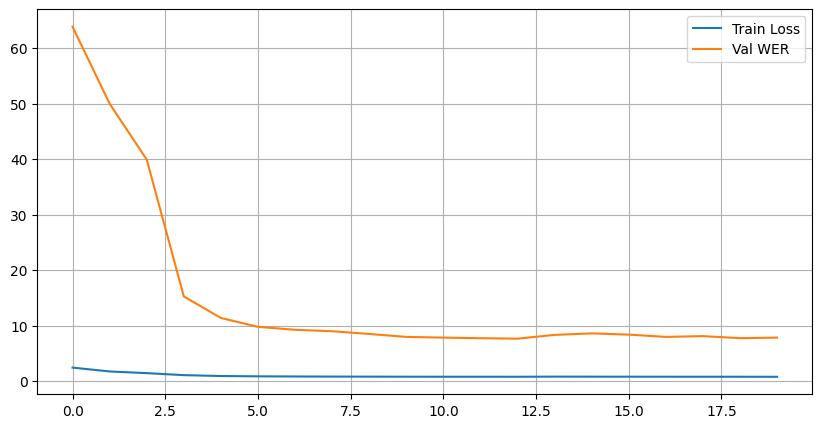

Initializing GPT‑2 decoder for English OCR...
Loaded 147 pretrained layers. Missing: 98
GPT‑2 decoder ready.


/tmp/ipykernel_3152070/366250695.py:599: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_path, map_location=device)


Loaded best model from epoch 13 (WER: 7.657021877205364%)


Testing:   0%|                                        | 1/2392 [01:10<46:55:53, 70.66s/it]

In [ ]:
# ============================================================
# ICDAR HWD 2024 — WORD LEVEL OCR (GPT‑2 PIPELINE)
# Swin + BiLSTM + GPT‑2 + LLRD + Agentic Verification (NO TPS)
# ============================================================

import os
import random
import numpy as np
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

from tqdm import tqdm
import matplotlib.pyplot as plt
import timm
from transformers import GPT2LMHeadModel, GPT2Config
import Levenshtein
from jiwer import wer

# ============================================================
# DEVICE
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# ============================================================
# CONFIGURATION
# ============================================================
DATASET_ROOT = "/home/mca24-26/ocr/dataset/Word_Level_English_Training_Set/Word_Level_Training_Set"
GT_FILE = "train.txt"
SAVE_DIR = "/home/mca24-26/ocr/saved_models/icdar_gpt_no_tps"
os.makedirs(SAVE_DIR, exist_ok=True)

BATCH_SIZE = 32
NUM_EPOCHS = 40
LEARNING_RATE = 5e-5
NUM_WORKERS = 4
MAX_LABEL_LEN = 25
IMG_H = 64
IMG_W = 256
VAL_SPLIT = 0.1
PATIENCE = 8

D_MODEL = 768
BEAM_SIZE = 5

# ============================================================
# VOCABULARY (same as ICDAR)
# ============================================================
CHARS = ' !"#$%&\'()*+,-./0123456789:;<=>?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[\\]^_`abcdefghijklmnopqrstuvwxyz{|}~'
GO_IDX  = 0
EOS_IDX = 1
PAD_IDX = 2
UNK_IDX = 3

CHAR_TO_IDX = {c: i + 4 for i, c in enumerate(CHARS)}
IDX_TO_CHAR = {v: k for k, v in CHAR_TO_IDX.items()}
IDX_TO_CHAR.update({GO_IDX: "<GO>", EOS_IDX: "<EOS>", PAD_IDX: "<PAD>", UNK_IDX: "<UNK>"})

VOCAB_SIZE = len(CHARS) + 4
PAD_IDX = PAD_IDX
SOS_IDX = GO_IDX
EOS_IDX = EOS_IDX

print("VOCAB SIZE =", VOCAB_SIZE)

# ============================================================
# LABEL ENCODING / DECODING
# ============================================================
def encode_label(text, max_len):
    tokens = [SOS_IDX]
    for c in text[:max_len]:
        tokens.append(CHAR_TO_IDX.get(c, UNK_IDX))
    tokens.append(EOS_IDX)
    while len(tokens) < max_len + 2:
        tokens.append(PAD_IDX)
    return torch.tensor(tokens[:max_len+2], dtype=torch.long)

def decode_label(tensor):
    chars = []
    for idx in tensor.tolist():
        if idx in [EOS_IDX, PAD_IDX]:
            break
        if idx in [SOS_IDX, UNK_IDX]:
            continue
        chars.append(IDX_TO_CHAR.get(idx, ""))
    return "".join(chars)

# ============================================================
# TRANSFORMS (RGB conversion for Swin)
# ============================================================
def get_transforms(imgH, imgW, augment=False):
    ops = [
        transforms.Resize((imgH, imgW)),
    ]
    if augment:
        ops += [
            transforms.RandomAffine(degrees=2, translate=(0.02, 0.02), scale=(0.95, 1.05), shear=2)
        ]
    ops += [
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]
    return transforms.Compose([
        transforms.Lambda(lambda img: img.convert('RGB') if img.mode != 'RGB' else img)
    ] + ops)

# ============================================================
# DATASET (unchanged)
# ============================================================
def load_gt_file(gt_path, dataset_root, max_label_len):
    samples = []
    with open(gt_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.rstrip('\n')
            if '\t' not in line:
                continue
            rel_path, label = line.split('\t', 1)
            label = label.strip()
            if len(label) == 0 or len(label) > max_label_len:
                continue
            abs_path = os.path.join(dataset_root, rel_path)
            if os.path.exists(abs_path):
                samples.append((abs_path, label))
    print(f"Loaded samples : {len(samples)}")
    return samples

class ICDARWordDataset(Dataset):
    def __init__(self, samples, max_label_len=25, imgH=32, imgW=160, augment=False):
        self.samples = samples
        self.max_label_len = max_label_len
        self.transform = get_transforms(imgH, imgW, augment)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            image = Image.open(img_path).convert('RGB')
        except:
            image = Image.new('RGB', (IMG_W, IMG_H), (255,255,255))
        image = self.transform(image)
        encoded = encode_label(label, self.max_label_len)
        return image, encoded, label

# ============================================================
# SPLIT (unchanged)
# ============================================================
def make_train_val_split(samples, val_fraction=0.1):
    samples = samples.copy()
    random.seed(42)
    random.shuffle(samples)
    n_val = int(len(samples) * val_fraction)
    val_samples = samples[:n_val]
    train_samples = samples[n_val:]
    print("Train =", len(train_samples))
    print("Val   =", len(val_samples))
    return train_samples, val_samples

# ============================================================
# LOAD DATA (unchanged)
# ============================================================
gt_path = os.path.join(DATASET_ROOT, GT_FILE)
all_samples = load_gt_file(gt_path, DATASET_ROOT, MAX_LABEL_LEN)
train_samples, val_samples = make_train_val_split(all_samples, VAL_SPLIT)

train_ds = ICDARWordDataset(train_samples, MAX_LABEL_LEN, IMG_H, IMG_W, augment=True)
val_ds   = ICDARWordDataset(val_samples,   MAX_LABEL_LEN, IMG_H, IMG_W, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# ============================================================
# ARCHITECTURE – NO TPS
# ============================================================

# ---- Swin Encoder (unchanged) ----
class SwinEncoder(nn.Module):
    def __init__(self, d_model=768):
        super().__init__()
        self.swin = timm.create_model(
            "swin_base_patch4_window7_224",
            pretrained=True,
            features_only=True,
            img_size=(IMG_H, IMG_W),
            strict_img_size=False,
        )
        self.proj = nn.Linear(512, d_model)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        features = self.swin(x)
        feat = features[-2]          # stage 3
        B, H, W, C = feat.shape
        feat = feat.view(B, H*W, C)
        return self.norm(self.proj(feat))

# ---- GPT-2 Decoder (unchanged) ----
class GPT2Decoder(nn.Module):
    def __init__(self, vocab_size, d_model=768):
        super().__init__()
        print("Initializing GPT‑2 decoder for English OCR...")
        config = GPT2Config.from_pretrained("gpt2")
        config.add_cross_attention = True
        config.vocab_size = vocab_size
        self.decoder = GPT2LMHeadModel(config)

        try:
            pretrained = GPT2LMHeadModel.from_pretrained("gpt2")
            pretrained_dict = pretrained.state_dict()
            mismatch_keys = {"transformer.wte.weight", "lm_head.weight"}
            filtered_dict = {k: v for k, v in pretrained_dict.items() if k not in mismatch_keys}
            load_result = self.decoder.load_state_dict(filtered_dict, strict=False)
            print(f"Loaded {len(filtered_dict)} pretrained layers. Missing: {len(load_result.missing_keys)}")
            del pretrained
        except Exception as e:
            print("Could not load pretrained GPT‑2, using random init:", e)
        print("GPT‑2 decoder ready.")

    def forward(self, input_ids, encoder_hidden_states=None, labels=None):
        return self.decoder(
            input_ids=input_ids,
            encoder_hidden_states=encoder_hidden_states,
            labels=labels
        )

# ---- Complete Pipeline – TPS REMOVED ----
class CompleteHTRPipeline(nn.Module):
    def __init__(self, vocab_size, d_model=768, num_control_points=16):
        super().__init__()
        # TPS layer removed
        self.swin_encoder = SwinEncoder(d_model=d_model)
        self.bilstm = nn.LSTM(
            input_size=d_model, hidden_size=d_model//2, num_layers=2,
            batch_first=True, bidirectional=True, dropout=0.3
        )
        self.gpt2_decoder = GPT2Decoder(vocab_size=vocab_size, d_model=d_model)

    def _extract_visual_memory(self, images):
        # No TPS – pass directly to Swin
        swin_feat = self.swin_encoder(images)
        memory, _ = self.bilstm(swin_feat)
        return memory.contiguous()

    def forward(self, images, target_ids, criterion=None):
        memory = self._extract_visual_memory(images)
        dec_input = target_ids[:, :-1].clone()
        dec_input = torch.where(dec_input == -100, torch.ones_like(dec_input), dec_input)
        labels = target_ids[:, 1:].clone()

        outputs = self.gpt2_decoder(input_ids=dec_input, encoder_hidden_states=memory)
        logits = outputs.logits

        if criterion is not None:
            return criterion(logits.reshape(-1, logits.size(-1)), labels.reshape(-1))
        return F.cross_entropy(logits.reshape(-1, logits.size(-1)), labels.reshape(-1), ignore_index=-100)

    @torch.no_grad()
    def generate(self, images, max_length=MAX_LABEL_LEN+1, bos_token_id=SOS_IDX, eos_token_id=EOS_IDX, beam_size=1):
        device = images.device
        B = images.size(0)
        memory = self._extract_visual_memory(images)

        if beam_size == 1:
            generated = torch.full((B, 1), bos_token_id, dtype=torch.long, device=device)
            finished = torch.zeros(B, dtype=torch.bool, device=device)
            for _ in range(max_length - 1):
                out = self.gpt2_decoder(input_ids=generated, encoder_hidden_states=memory)
                next_tokens = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)
                next_tokens = next_tokens.masked_fill(finished.unsqueeze(1), eos_token_id)
                generated = torch.cat([generated, next_tokens], dim=1)
                finished |= (next_tokens.squeeze(1) == eos_token_id)
                if finished.all():
                    break
            return generated[:, 1:]

        # Beam search (full implementation)
        all_results = []
        for b in range(B):
            mem = memory[b:b+1]
            beams = [(0.0, [bos_token_id])]
            completed = []
            for _ in range(max_length - 1):
                candidates = []
                for score, tokens in beams:
                    if tokens[-1] == eos_token_id:
                        completed.append((score, tokens))
                        continue
                    inp = torch.tensor([tokens], dtype=torch.long, device=device)
                    out = self.gpt2_decoder(input_ids=inp, encoder_hidden_states=mem)
                    log_prob = F.log_softmax(out.logits[0, -1], dim=-1)
                    top_lp, top_id = log_prob.topk(beam_size)
                    for lp, tid in zip(top_lp.tolist(), top_id.tolist()):
                        candidates.append((score + lp, tokens + [tid]))
                if not candidates:
                    break
                candidates.sort(key=lambda x: x[0], reverse=True)
                beams = []
                for score, tokens in candidates[:beam_size * 2]:
                    if tokens[-1] == eos_token_id:
                        completed.append((score, tokens))
                    else:
                        beams.append((score, tokens))
                    if len(beams) == beam_size:
                        break
                if not beams:
                    break
            all_beams = completed if completed else beams
            _, best_tokens = max(all_beams, key=lambda x: x[0])
            result = torch.tensor(best_tokens[1:], dtype=torch.long, device=device)
            all_results.append(result)

        max_len = max(r.size(0) for r in all_results)
        padded = torch.full((B, max_len), eos_token_id, dtype=torch.long, device=device)
        for i, r in enumerate(all_results):
            padded[i, :r.size(0)] = r
        return padded

# ============================================================
# LLRD OPTIMIZER – WITHOUT TPS
# ============================================================
def build_llrd_optimizer(model, base_lr=5e-5, decay_factor=0.75, weight_decay=0.05):
    assigned = set()
    def collect(named_params, filter_fn):
        params = []
        for name, param in named_params:
            if id(param) not in assigned and filter_fn(name):
                params.append(param)
                assigned.add(id(param))
        return params
    def collect_all(named_params):
        params = []
        for name, param in named_params:
            if id(param) not in assigned:
                params.append(param)
                assigned.add(id(param))
        return params

    # GPT-2 cross-attention (new layers)
    gpt2_crossattn = collect(model.gpt2_decoder.named_parameters(),
                             lambda n: "crossattention" in n or "cross_attn" in n)
    # GPT-2 rest
    gpt2_rest = collect_all(model.gpt2_decoder.named_parameters())
    bilstm_params = collect_all(model.bilstm.named_parameters())
    swin_proj = collect(model.swin_encoder.named_parameters(),
                        lambda n: n.startswith("proj.") or n.startswith("norm."))
    swin_s4 = collect(model.swin_encoder.swin.named_parameters(),
                      lambda n: "layers_3" in n)
    swin_s3 = collect(model.swin_encoder.swin.named_parameters(),
                      lambda n: "layers_2" in n)
    swin_s2 = collect(model.swin_encoder.swin.named_parameters(),
                      lambda n: "layers_1" in n)
    swin_s1 = collect_all(model.swin_encoder.swin.named_parameters())

    # TPS group removed – we have 8 groups now
    lr = [
        base_lr,
        base_lr * decay_factor,
        base_lr * decay_factor**2,
        base_lr * decay_factor**3,
        base_lr * decay_factor**4,
        base_lr * decay_factor**5,
        base_lr * decay_factor**6,
        base_lr * decay_factor**7,
    ]

    groups = [
        (gpt2_crossattn, lr[0], "gpt2_crossattn"),
        (gpt2_rest,      lr[1], "gpt2_rest"),
        (bilstm_params,  lr[2], "bilstm"),
        (swin_proj,      lr[3], "swin_proj"),
        (swin_s4,        lr[4], "swin_stage4"),
        (swin_s3,        lr[5], "swin_stage3"),
        (swin_s2,        lr[6], "swin_stage2"),
        (swin_s1,        lr[7], "swin_stage1"),
    ]

    param_groups = [{"params": p, "lr": l, "name": n} for p, l, n in groups if len(p) > 0]
    print("\nLLRD Groups (without TPS):")
    print(f"{'Name':<20} {'LR':>10} {'Params':>10}")
    print("-" * 44)
    for g in param_groups:
        n = sum(p.numel() for p in g["params"])
        print(f"{g['name']:<20} {g['lr']:>10.2e} {n/1e6:>9.2f}M")
    return optim.AdamW(param_groups, weight_decay=weight_decay)

# ============================================================
# AGENTIC VERIFICATION (unchanged)
# ============================================================
class AgenticVerificationModule:
    def __init__(self, train_samples):
        self.lexicon = defaultdict(int)
        for _, text in train_samples:
            for word in text.split():
                clean = word.strip(".,!?()[]{}:;\"'").lower()
                if clean:
                    self.lexicon[clean] += 1
        self.freq_max = max(self.lexicon.values()) if self.lexicon else 1
        print(f"Lexicon built: {len(self.lexicon)} unique words, max freq {self.freq_max}")

    def verify_and_correct(self, text_output, confidence=None, confidence_threshold=0.85):
        cleaned = text_output.strip().lower()
        if (not cleaned
                or cleaned in self.lexicon
                or len(cleaned) <= 2
                or any(c.isdigit() for c in cleaned)):
            return text_output
        if confidence is not None and confidence >= confidence_threshold:
            return text_output

        best_candidate = None
        best_score = -float('inf')
        target_len = len(cleaned)

        for word, freq in self.lexicon.items():
            if abs(len(word) - target_len) > 2:
                continue
            dist = Levenshtein.distance(cleaned, word)
            if dist > 2:
                continue
            freq_score = freq / self.freq_max
            score = freq_score - (dist * 1.2)
            if score > best_score:
                best_score = score
                best_candidate = word

        if best_candidate is None:
            return text_output

        if text_output.isupper():
            return best_candidate.upper()
        elif len(text_output) > 0 and text_output[0].isupper():
            return best_candidate.capitalize()
        return best_candidate

# ============================================================
# METRICS & EARLY STOPPING (unchanged)
# ============================================================
def char_accuracy(preds, labels):
    correct = 0
    total = 0
    for p, l in zip(preds, labels):
        n = min(len(p), len(l))
        for i in range(n):
            if p[i] == l[i]:
                correct += 1
        total += max(len(p), len(l))
    return 100.0 * correct / max(total, 1)

def calculate_metrics(preds, targets):
    cer = char_accuracy(preds, targets)
    wer_val = wer(targets, preds) * 100
    return {"CER": cer, "WER": wer_val}

class EarlyStopping:
    def __init__(self, patience=8, min_delta=0.05):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best = float('inf')
        self.early_stop = False

    def __call__(self, metric):
        if metric < self.best - self.min_delta:
            self.best = metric
            self.counter = 0
        else:
            self.counter += 1
            print(f"EarlyStopping: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        return self.early_stop

# ============================================================
# TRAINING LOOP (unchanged)
# ============================================================
def train():
    model = CompleteHTRPipeline(vocab_size=VOCAB_SIZE).to(device)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params/1e6:.2f}M")

    # Freeze Swin for first 3 epochs
    for param in model.swin_encoder.swin.parameters():
        param.requires_grad = False

    optimizer = build_llrd_optimizer(model, base_lr=LEARNING_RATE, decay_factor=0.75, weight_decay=0.05)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-7)

    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)
    scaler = torch.amp.GradScaler('cuda', enabled=True)

    agent_verifier = AgenticVerificationModule(train_samples)
    early_stopper = EarlyStopping(patience=PATIENCE, min_delta=0.1)

    best_val_wer = float('inf')
    history = {"train_loss": [], "val_wer": []}

    for epoch in range(1, NUM_EPOCHS + 1):
        # Unfreeze Swin after epoch 3
        if epoch == 4:
            for param in model.swin_encoder.swin.parameters():
                param.requires_grad = True
            optimizer = build_llrd_optimizer(model, base_lr=LEARNING_RATE, decay_factor=0.75, weight_decay=0.05)
            scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-7)
            print("Swin encoder unfrozen.")

        # ---- Train ----
        model.train()
        train_loss = 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [Train]")
        for images, targets, _ in pbar:
            images = images.to(device)
            targets = targets.to(device)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda', enabled=True):
                loss = model(images, target_ids=targets, criterion=criterion)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        scheduler.step()
        avg_train_loss = train_loss / len(train_loader)

        # ---- Validation ----
        model.eval()
        all_preds, all_labels = [], []
        first_batch_done = False
        with torch.no_grad():
            for images, _, texts in tqdm(val_loader, desc="Validation"):
                images = images.to(device)
                tokens = model.generate(images, beam_size=1)
                preds = [decode_label(x) for x in tokens]
                verified_preds = [agent_verifier.verify_and_correct(p) for p in preds]
                all_preds.extend(verified_preds)
                all_labels.extend(texts)

                if not first_batch_done:
                    print("\n--- Sample validation predictions ---")
                    for i in range(min(3, len(preds))):
                        print(f"Target: '{texts[i]}' | Pred: '{preds[i]}' -> Verified: '{verified_preds[i]}'")
                    first_batch_done = True

        metrics = calculate_metrics(all_preds, all_labels)
        val_cer = metrics["CER"]
        val_wer = metrics["WER"]
        history["train_loss"].append(avg_train_loss)
        history["val_wer"].append(val_wer)

        print(f"\nEpoch {epoch} | Train Loss: {avg_train_loss:.4f} | Val CER: {val_cer:.2f}% | Val WER: {val_wer:.2f}%")

        if val_wer < best_val_wer:
            best_val_wer = val_wer
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_wer': val_wer,
                'cer': val_cer,
            }, os.path.join(SAVE_DIR, "icdar_gpt_notps.pth"))
            print(f"Best model saved (WER: {val_wer:.2f}%)")

        if early_stopper(val_wer):
            print("Early stopping triggered.")
            break

    torch.save(model.state_dict(), os.path.join(SAVE_DIR, "last_icdar_gpt_notps.pth"))
    print("Training finished.")

    # Plot loss curve
    plt.figure(figsize=(10,5))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_wer"], label="Val WER")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(SAVE_DIR, "training_curve.png"))
    plt.show()

# ============================================================
# TEST EVALUATION (unchanged)
# ============================================================
def test(use_beam_search=True):
    model = CompleteHTRPipeline(vocab_size=VOCAB_SIZE).to(device)
    best_path = os.path.join(SAVE_DIR, "icdar_gpt_notps.pth")
    if os.path.exists(best_path):
        ckpt = torch.load(best_path, map_location=device)
        model.load_state_dict(ckpt['model_state_dict'])
        print(f"Loaded best model from epoch {ckpt.get('epoch', '?')} (WER: {ckpt.get('best_wer', '?')}%)")
    else:
        print("No best checkpoint found, using random weights.")
        return

    model.eval()
    test_preds, test_labels = [], []
    with torch.no_grad():
        for images, _, texts in tqdm(test_loader, desc="Testing"):
            images = images.to(device)
            beam = BEAM_SIZE if use_beam_search else 1
            tokens = model.generate(images, beam_size=beam)
            preds = [decode_label(x) for x in tokens]
            test_preds.extend(preds)
            test_labels.extend(texts)

    test_cer = char_accuracy(test_preds, test_labels)
    test_wer = wer(test_labels, test_preds) * 100
    print(f"\nTest CER: {test_cer:.2f}% | Test WER: {test_wer:.2f}%")

    print("\nSample predictions:")
    for i in range(min(10, len(test_preds))):
        print(f"GT : {test_labels[i]}")
        print(f"PR : {test_preds[i]}")
        print("-" * 40)

# ============================================================
# MAIN
# ============================================================
if __name__ == "__main__":
    # Create test loader (use same split as validation for testing)
    test_samples, _ = make_train_val_split(all_samples, val_fraction=0.1)
    test_ds = ICDARWordDataset(test_samples, MAX_LABEL_LEN, IMG_H, IMG_W, augment=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    train()
    test(use_beam_search=True)